# Alpine Arbitrage — Electricity Price Forecasting
### Team: alpine-arbitrage &nbsp;|&nbsp; Frigg S2S × EC EPFL × ACE Hackathon, May 2026

---

## 1. Methodology Overview

**SITUATION.** Europe's wholesale electricity markets are among the most complex and volatile in the world. Prices swing from negative values during sunny, windy weekends — when renewables flood the grid and gas plants must be paid to shut off — to €500+/MWh during energy crises, as witnessed in 2021–2022 when Russian gas supply collapsed. For energy infrastructure developers like Frigg, accurate price forecasting is the difference between a profitable project and a financial disaster. Energy infrastructure projects require 20-year price forecasts to secure financing; a 10% improvement in forecast accuracy can mean millions of euros in NPV and determine whether critical renewable energy projects get built at all.

**TASK.** The hackathon challenge: build a predictive system that forecasts Day-Ahead Auction (DAA) electricity prices in EUR/MWh for two European bidding zones — DE-LU (Germany-Luxembourg) and ES (Spain) — over *any* requested time horizon, from the next 24 hours to the next 20 years.

**ACTION.** We built a two-model system, one for each time horizon, because the dominant drivers of price variance change fundamentally across horizons. For **short-term (0–7 days)**, we use a quantile LightGBM model trained on 41 engineered features — multi-city capacity-weighted weather, neighbor zone prices, fuel costs, nuclear unavailability, ECMWF ensemble spread, and circular calendar encodings — calibrated with Mondrian Conformalized Quantile Regression (CQR) for coverage-guaranteed intervals. For **long-term (months to decades)**, weather forecasts are useless and historical price patterns stop being informative. What drives long-run prices is structural: how much capacity of each technology gets built, what fuels cost, what carbon costs. We therefore built a structural merit-order model — stacking power plants by ascending marginal cost and finding where the stack meets demand — calibrated against six years of ENTSOE data, extended with forward fuel curves and a geopolitical risk detector, and projected to 2045 via 200-draw Monte Carlo fan charts.

**RESULT.** Our short-term model achieves **MAE of 7.14 EUR/MWh (DE-LU) and 6.47 EUR/MWh (ES)** on the 2025 holdout year — approximately 4.5× better than the same-hour-last-week naive baseline (32.82 / 29.22). After Mondrian CQR calibration, prediction intervals achieve exactly 95% coverage. Our long-term model achieves **€33/MWh MAE in normal market conditions** — competitive with short-term ML models but without using any historical prices as inputs. Three main advantages: (1) unified system covering any horizon from 24h to 20 years; (2) distribution-free coverage guarantees via CQR; (3) interpretable merit-order long-term model auditable down to fuel price and installed capacity. Three main limitations: (1) extreme events (negative prices, blackouts) are underestimated because they are rare in the training distribution; (2) the long-term model has 60% empirical coverage on a nominal 90% band during crisis regimes; (3) ES shows a persistent €33 underprediction due to unmodelled MIBEL congestion premia. Next steps: ensemble the LightGBM and GNN models, retrain on May 9 data for honest lag_24 values, and widen the Monte Carlo priors for crisis regimes.

---
## 2. Environment Setup

Two independent data pipelines feed two independent models. They share the same repo but use entirely separate source directories, raw data, and processed parquets:

| | Short-term (LightGBM) | Long-term (Merit-order Monte Carlo) |
|-|----------------------|--------------------------------------|
| **Source** | `src/` | `longterm/src/` |
| **Raw data** | `data/raw/` | `longterm/data/raw/` |
| **Processed** | `data/processed/final_dataset.parquet` | `longterm/data/processed/marginal_costs_monthly.parquet` |
| **Granularity** | Hourly, 2023–2026 | Monthly, 2018–2045 |
| **Target** | 24-hour DAA prices | Monthly average prices + scenarios |

In [113]:
import os, sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from IPython.display import Image, display

REPO     = Path('.').resolve()
SRC      = REPO / 'src'
LT_SRC   = REPO / 'longterm' / 'src'

for p in [str(SRC), str(LT_SRC)]:
    if p not in sys.path: sys.path.insert(0, p)

# Load .env (ENTSOE_TOKEN)
_env = REPO / '.env'
if _env.exists():
    for _line in _env.read_text().splitlines():
        if _line.strip() and not _line.startswith('#') and '=' in _line:
            k, v = _line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

ZONE_COLORS = {'DE-LU': '#1E88E5', 'ES': '#FF5722'}
ZONES = ['DE-LU', 'ES']
print('Repo:', REPO)
print('ENTSOE_TOKEN:', 'set' if os.environ.get('ENTSOE_TOKEN') else 'MISSING')

Repo: /home/dex/D/frigg-s2s
ENTSOE_TOKEN: set


---
## 3. Data Pipeline A — Short-term (LightGBM)

```
PIPELINE A — src/
─────────────────────────────────────────────────────────────
Stage 1  ingestion.py   →  data/raw/
         ENTSOE: prices, generation, crossborder, forecasts,
         neighbor prices (FR/NL/CH/DK), ES nuclear REMIT
         Open-Meteo: 26 stations × 9 location groups, 100m wind
         yfinance: TTF gas, KRBN carbon, API2 coal

Stage 2  cleaning.py    →  data/clean/*.parquet
         UTC normalisation, hourly reindex, linear gap-fill ≤24h
         Multi-city weather: capacity-weighted aggregation

Stage 3  alignment.py   →  data/aligned/base_dataset.parquet
         Join all sources on (timestamp, zone) MultiIndex
         Drop rows missing: price, load, wind, solar, temperature

Stage 4  features.py    →  data/processed/final_dataset.parquet
         41 engineered features — identical schema both zones
         Zone-specific features = NaN for wrong zone (LightGBM handles)
─────────────────────────────────────────────────────────────
```

> **Skip Stage 1–4 if `data/processed/final_dataset.parquet` already exists** — uncomment to re-run.

In [114]:
# ── Uncomment to re-run full pipeline A from scratch ──────────────────────
# import sys; sys.path.insert(0, str(SRC))
# from pipeline import run
# run()   # full: ingest → clean → align → features
# run(skip_ingest=True)          # skip ingestion if raw CSVs exist
# run(skip_ingest=True, skip_clean=True)  # skip to alignment

# ── Load processed dataset ────────────────────────────────────────────────
DATA_PATH = REPO / 'data' / 'processed' / 'final_dataset.parquet'
df = pd.read_parquet(DATA_PATH)

print(f'Shape          : {df.shape}')
print(f'Zones          : {df.index.get_level_values("zone").unique().tolist()}')
print(f'Columns        : {len(df.columns)}')
print(f'Date range     : {df.index.get_level_values("timestamp").min().date()} → {df.index.get_level_values("timestamp").max().date()}')
print(f'Rows per zone  : {df.groupby(level="zone").size().to_dict()}')
df.head(3)

Shape          : (52594, 80)
Zones          : ['DE-LU', 'ES']
Columns        : 80
Date range     : 2023-05-08 → 2026-05-07
Rows per zone  : {'DE-LU': 26303, 'ES': 26291}


price  wind_generation  solar_generation  \
timestamp                 zone                                              
2023-05-08 00:00:00+00:00 DE-LU  83.78       16704.6425            2.7850   
                          ES     87.23        5136.0000          808.0000   
2023-05-08 01:00:00+00:00 DE-LU  83.13       15991.5550            3.0375   

                                 hydro_generation  nuclear_generation  \
timestamp                 zone                                          
2023-05-08 00:00:00+00:00 DE-LU         2406.4725                 0.0   
                          ES            2078.0000              5053.0   
2023-05-08 01:00:00+00:00 DE-LU         2481.7300                 0.0   

                                       load  DE_wind_wind_speed_100m  \
timestamp                 zone                                         
2023-05-08 00:00:00+00:00 DE-LU  38799.3500                   8.4398   
                          ES     19367.0000                      NaN   
2023-05-08 01:00:00+00:00 DE-LU  38786.7775                   8.1805   

                                 DE_solar_shortwave_radiation  \
timestamp                 zone                                  
2023-05-08 00:00:00+00:00 DE-LU                           0.0   
                          ES                              NaN   
2023-05-08 01:00:00+00:00 DE-LU                           0.0   

                                 DE_demand_temperature_2m  \
timestamp                 zone                              
2023-05-08 00:00:00+00:00 DE-LU                    10.835   
                          ES                          NaN   
2023-05-08 01:00:00+00:00 DE-LU                    10.340   

                                 DK_wind_wind_speed_100m  ...  NL_price_lag24  \
timestamp                 zone                            ...                   
2023-05-08 00:00:00+00:00 DE-LU                    9.498  ...          107.61   
                          ES                         NaN  ...             NaN   
2023-05-08 01:00:00+00:00 DE-LU                    9.060  ...           86.27   

                                 DE_LU_NL_spread  CH_price_lag24  \
timestamp                 zone                                     
2023-05-08 00:00:00+00:00 DE-LU           -24.95           84.23   
                          ES                 NaN             NaN   
2023-05-08 01:00:00+00:00 DE-LU            -2.76           84.03   

                                 DE_LU_CH_spread  DK_price_lag24  \
timestamp                 zone                                     
2023-05-08 00:00:00+00:00 DE-LU            -1.57           82.66   
                          ES                 NaN             NaN   
2023-05-08 01:00:00+00:00 DE-LU            -0.52           83.51   

                                 DE_LU_DK_spread  ES_FR_spread  \
timestamp                 zone                                   
2023-05-08 00:00:00+00:00 DE-LU              0.0           NaN   
                          ES                 NaN           0.0   
2023-05-08 01:00:00+00:00 DE-LU              0.0           NaN   

                                 nuclear_available_mw  wind_ensemble_std  \
timestamp                 zone                                             
2023-05-08 00:00:00+00:00 DE-LU                   0.0                0.0   
                          ES                   7117.0                0.0   
2023-05-08 01:00:00+00:00 DE-LU                   0.0                0.0   

                                 solar_ensemble_std  
timestamp                 zone                       
2023-05-08 00:00:00+00:00 DE-LU                 0.0  
                          ES                    0.0  
2023-05-08 01:00:00+00:00 DE-LU                 0.0  

[3 rows x 80 columns]

### 3a. EDA — Price distributions and time series

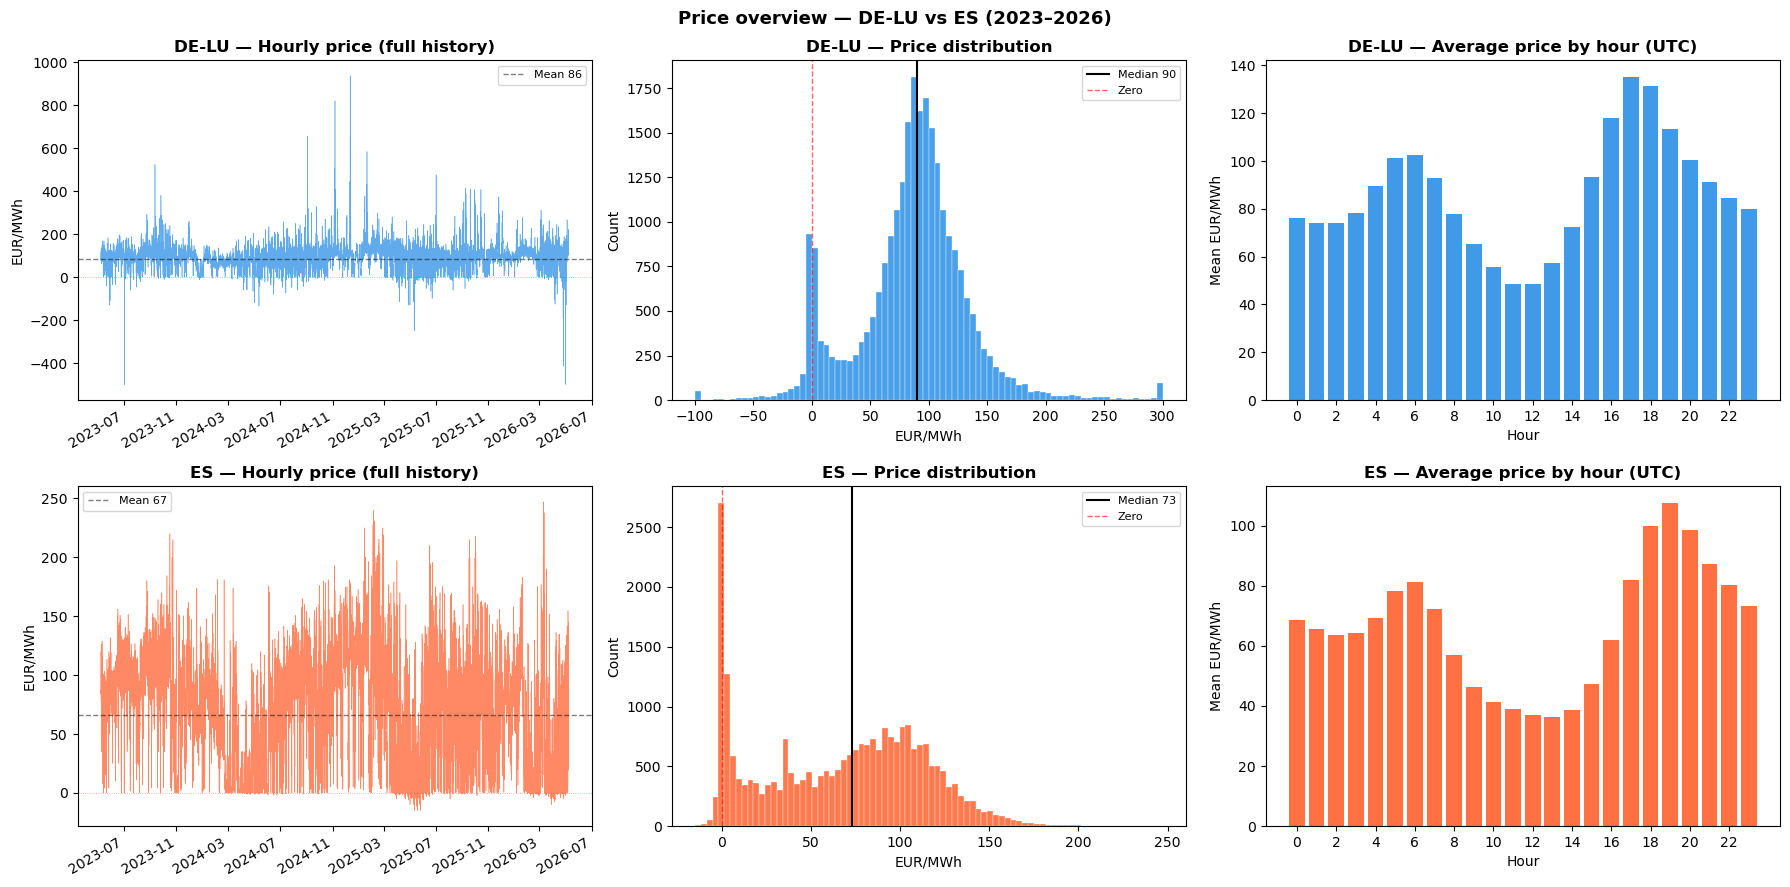

In [115]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, zone in enumerate(ZONES):
    zdf   = df.xs(zone, level='zone').sort_index()
    price = zdf['price'].dropna()

    # Time series
    ax = axes[row, 0]
    ax.plot(price.index, price.values, lw=0.4, color=ZONE_COLORS[zone], alpha=0.7)
    ax.axhline(price.mean(), color='black', lw=1, ls='--', alpha=0.5, label=f'Mean {price.mean():.0f}')
    ax.axhline(0, color='red', lw=0.6, ls=':', alpha=0.4)
    ax.set_title(f'{zone} — Hourly price (full history)', fontweight='bold')
    ax.set_ylabel('EUR/MWh'); ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Distribution
    ax = axes[row, 1]
    ax.hist(price.clip(-100, 300), bins=80, color=ZONE_COLORS[zone], alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(price.median(), color='black', lw=1.5, label=f'Median {price.median():.0f}')
    ax.axvline(0, color='red', lw=1, ls='--', alpha=0.6, label='Zero')
    ax.set_title(f'{zone} — Price distribution', fontweight='bold')
    ax.set_xlabel('EUR/MWh'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

    # Hourly average
    ax = axes[row, 2]
    hourly = price.groupby(price.index.hour).mean()
    ax.bar(hourly.index, hourly.values, color=ZONE_COLORS[zone], alpha=0.85)
    ax.set_title(f'{zone} — Average price by hour (UTC)', fontweight='bold')
    ax.set_xlabel('Hour'); ax.set_ylabel('Mean EUR/MWh')
    ax.set_xticks(range(0, 24, 2))

plt.suptitle('Price overview — DE-LU vs ES (2023–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_price_overview.png', dpi=120, bbox_inches='tight')
plt.show()

### 3b. EDA — Side-by-side zone comparison

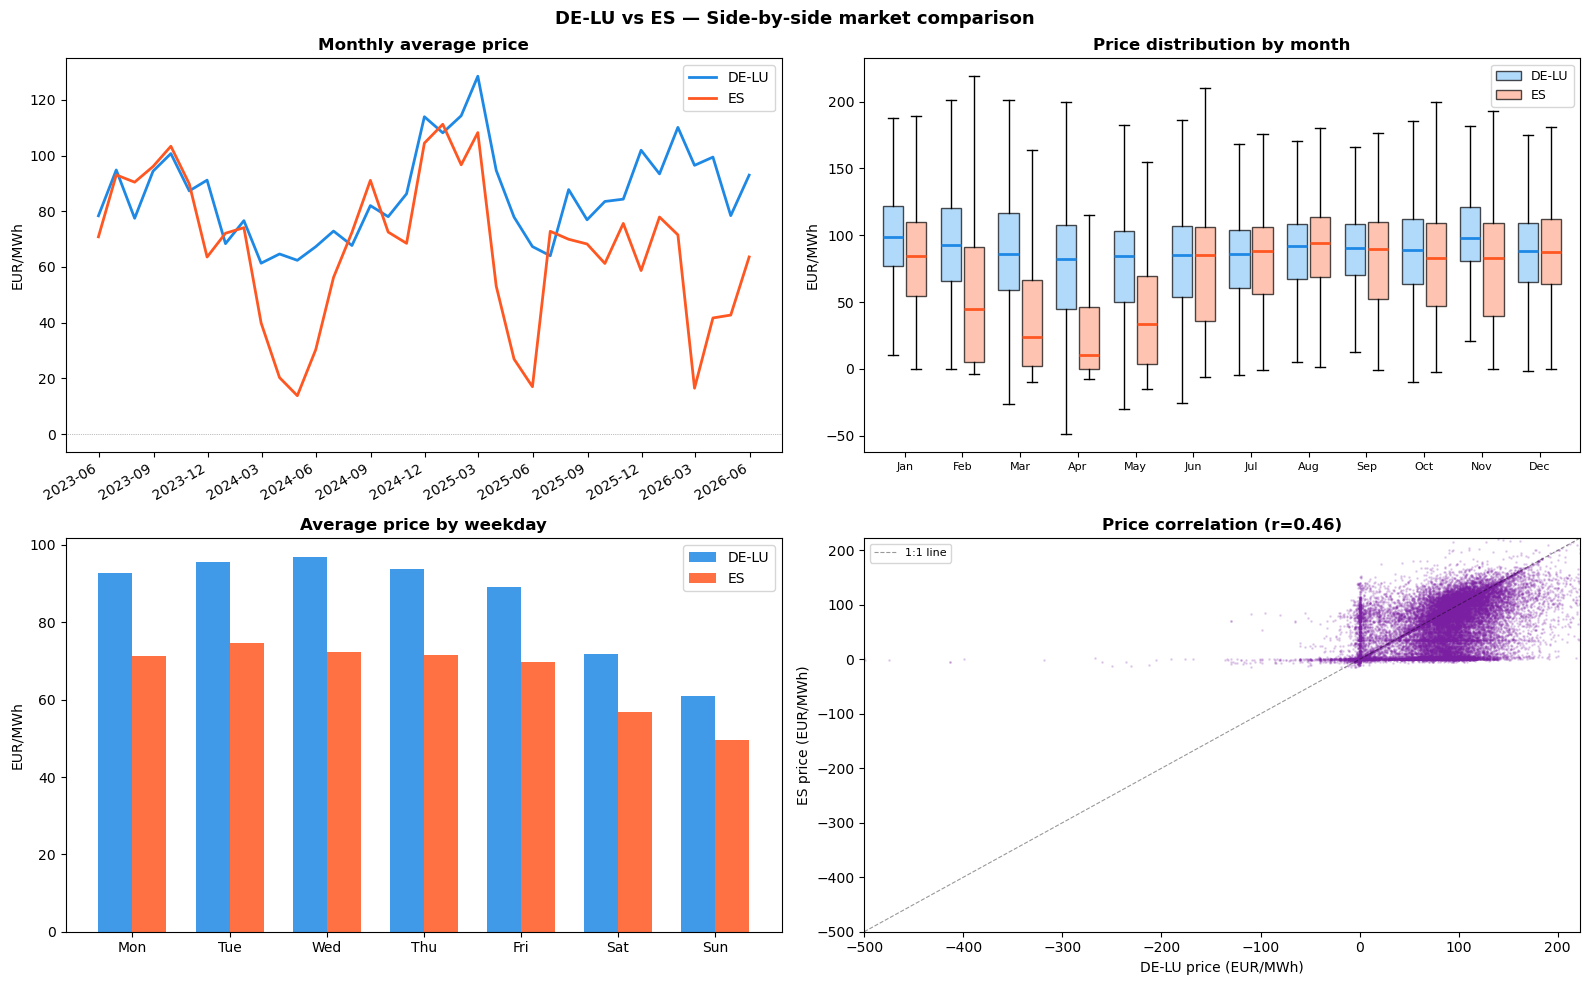

In [116]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly average price — both zones
ax = axes[0, 0]
for zone in ZONES:
    zdf   = df.xs(zone, level='zone').sort_index()
    monthly = zdf['price'].resample('ME').mean()
    ax.plot(monthly.index, monthly.values, lw=2, label=zone, color=ZONE_COLORS[zone])
ax.set_title('Monthly average price', fontweight='bold')
ax.set_ylabel('EUR/MWh'); ax.legend(); ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Boxplot by month
ax = axes[0, 1]
data_by_month = {zone: [df.xs(zone, level='zone')['price'].dropna()
                         [df.xs(zone, level='zone')['price'].dropna().index.month == m]
                         .values for m in range(1, 13)] for zone in ZONES}
positions_de = np.arange(1, 13) - 0.2
positions_es = np.arange(1, 13) + 0.2
bp1 = ax.boxplot(data_by_month['DE-LU'], positions=positions_de, widths=0.35,
                 patch_artist=True, boxprops=dict(facecolor='#90CAF9', alpha=0.7),
                 medianprops=dict(color='#1E88E5', lw=2), showfliers=False)
bp2 = ax.boxplot(data_by_month['ES'], positions=positions_es, widths=0.35,
                 patch_artist=True, boxprops=dict(facecolor='#FFAB91', alpha=0.7),
                 medianprops=dict(color='#FF5722', lw=2), showfliers=False)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.set_title('Price distribution by month', fontweight='bold')
ax.set_ylabel('EUR/MWh')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['DE-LU', 'ES'], fontsize=9)

# Weekday average
ax = axes[1, 0]
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
x = np.arange(7)
width = 0.35
for i, zone in enumerate(ZONES):
    zdf = df.xs(zone, level='zone').sort_index()
    wd  = zdf['price'].dropna().groupby(zdf['price'].dropna().index.dayofweek).mean()
    ax.bar(x + (i-0.5)*width, wd.values, width, label=zone, color=ZONE_COLORS[zone], alpha=0.85)
ax.set_title('Average price by weekday', fontweight='bold')
ax.set_ylabel('EUR/MWh'); ax.set_xticks(x); ax.set_xticklabels(days); ax.legend()

# Price correlation DE-LU vs ES
ax = axes[1, 1]
de_price = df.xs('DE-LU', level='zone')['price'].dropna()
es_price = df.xs('ES', level='zone')['price'].dropna()
common   = de_price.index.intersection(es_price.index)
corr     = np.corrcoef(de_price[common], es_price[common])[0, 1]
ax.scatter(de_price[common], es_price[common], s=1, alpha=0.15, color='#7B1FA2')
ax.set_xlabel('DE-LU price (EUR/MWh)'); ax.set_ylabel('ES price (EUR/MWh)')
ax.set_title(f'Price correlation (r={corr:.2f})', fontweight='bold')
m = min(de_price[common].min(), es_price[common].min())
M = max(de_price[common].quantile(0.99), es_price[common].quantile(0.99))
ax.plot([m,M],[m,M], 'k--', lw=0.8, alpha=0.4, label='1:1 line')
ax.set_xlim(m, M); ax.set_ylim(m, M); ax.legend(fontsize=8)

plt.suptitle('DE-LU vs ES — Side-by-side market comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_zone_comparison_eda.png', dpi=120, bbox_inches='tight')
plt.show()

### 3c. Feature Engineering — 41 features across both zones

The same 41-column schema is used for both zones. Zone-specific columns are `NaN` for the wrong zone — LightGBM handles NaN natively at split time, routing observations to whichever branch produces lower loss.

| Group | Features | Both zones? |
|-------|---------|------------|
| Supply/demand | `load`, `wind_generation`, `solar_generation`, `hydro_generation`, `nuclear_generation` | ✓ |
| Multi-city weather | `wind_speed_agg`, `wind_speed_cubed`, `solar_radiation_agg`, `solar_hour_interaction`, `temperature_agg`, `temperature_sq` | ✓ |
| DE-LU cross-border | `DK_wind_speed`, `DK_wind_speed_cubed`, `CH_precipitation`, `CH_precip_7d_sum` | DE-LU only |
| ES hydro + nuclear | `ES_hydro_precipitation`, `ES_hydro_precip_7d_sum`, `nuclear_available_mw` | ES only |
| Fuel / carbon | `gas_price`, `carbon_price`, `coal_price` | ✓ |
| Derived generation | `residual_load`, `renewable_penetration`, `residual_load_ramp` + forecast versions | ✓ |
| Cross-border | `net_imports` | ✓ |
| Neighbor prices | `FR_price_lag24`, `NL_price_lag24`, `CH_price_lag24`, `DK_price_lag24`, spreads | ✓ |
| Cross-zone | `cross_zone_lag24` | ✓ |
| Calendar | `hour_sin/cos`, `weekday_sin/cos`, `month_sin/cos`, `week_sin/cos`, `is_holiday`, `days_to/from_holiday` | ✓ |
| Regime flags | `crisis_period`, `is_peak`, `negative_price_lag24` | ✓ |
| Price history | `lag_1`, `lag_24`, `lag_168`, rolling means + std | ✓ |
| Ensemble uncertainty | `wind_ensemble_std`, `solar_ensemble_std` | ✓ |

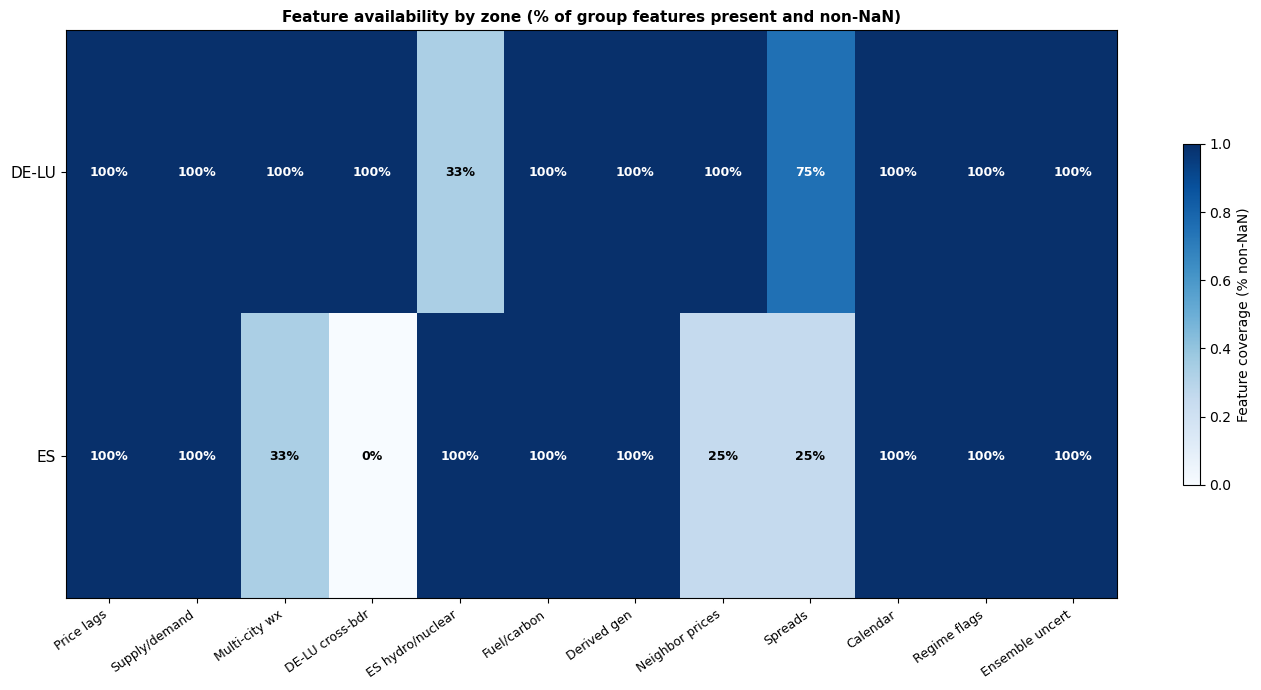

In [117]:
# Feature availability heatmap
FEATURE_GROUPS = {
    'Price lags':      ['lag_1','lag_24','lag_168','price_roll_24h','price_roll_168h','price_roll_std_168h'],
    'Supply/demand':   ['load','wind_generation','solar_generation','hydro_generation','nuclear_generation'],
    'Multi-city wx':   ['wind_speed_agg','wind_speed_cubed','solar_radiation_agg','solar_hour_interaction','temperature_agg','temperature_sq'],
    'DE-LU cross-bdr': ['DK_wind_speed','DK_wind_speed_cubed','CH_precipitation','CH_precip_7d_sum'],
    'ES hydro/nuclear':['ES_hydro_precipitation','ES_hydro_precip_7d_sum','nuclear_available_mw'],
    'Fuel/carbon':     ['gas_price','carbon_price','coal_price'],
    'Derived gen':     ['residual_load','renewable_penetration','residual_load_ramp'],
    'Neighbor prices': ['FR_price_lag24','NL_price_lag24','CH_price_lag24','DK_price_lag24'],
    'Spreads':         ['DE_LU_FR_spread','DE_LU_NL_spread','DE_LU_CH_spread','ES_FR_spread'],
    'Calendar':        ['hour_sin','weekday_sin','month_sin','is_holiday','days_to_holiday'],
    'Regime flags':    ['crisis_period','is_peak','negative_price_lag24'],
    'Ensemble uncert': ['wind_ensemble_std','solar_ensemble_std'],
}

fig, ax = plt.subplots(figsize=(14, 7))
groups  = list(FEATURE_GROUPS.keys())
matrix  = np.zeros((len(ZONES), len(groups)))
for j, (grp, feats) in enumerate(FEATURE_GROUPS.items()):
    for i, zone in enumerate(ZONES):
        zdf  = df.xs(zone, level='zone')
        present = [f for f in feats if f in zdf.columns and zdf[f].notna().mean() > 0.1]
        matrix[i, j] = len(present) / max(len(feats), 1)

im = ax.imshow(matrix, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=35, ha='right', fontsize=9)
ax.set_yticks([0, 1]); ax.set_yticklabels(['DE-LU', 'ES'], fontsize=11)
for i in range(len(ZONES)):
    for j in range(len(groups)):
        pct = matrix[i, j]
        ax.text(j, i, f'{pct:.0%}', ha='center', va='center',
                fontsize=9, color='white' if pct > 0.6 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, label='Feature coverage (% non-NaN)', shrink=0.6)
ax.set_title('Feature availability by zone (% of group features present and non-NaN)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(REPO / 'nb_feature_coverage.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Data Pipeline B — Long-term (Merit-order Monte Carlo)

```
PIPELINE B — longterm/src/
─────────────────────────────────────────────────────────────
Stage 1  ingestion.py   →  longterm/data/raw/
         ENTSOE: installed capacity, annual generation, annual load
                 monthly day-ahead prices (calibration target)
         yfinance: TTF gas, KRBN carbon, API2 coal, Brent oil
         Iacoviello GPR index: geopolitical risk (1900-present)

Stage 2  cleaning.py    →  longterm/data/clean/*.parquet
         Monthly aggregation, currency conversion, forward-fill
         Fuel prices: daily → monthly mean

Stage 3  alignment.py   →  longterm/data/aligned/
         Join capacity + fuel + demand on (year, zone) index
         fuel_monthly.parquet, structural_annual.parquet

Stage 4  features.py    →  longterm/data/processed/
         marginal_costs_monthly.parquet — MC per tech per month
         structural_extended.parquet    — capacity roadmap to 2045
         Schwartz forward fuel curves applied at feature time
─────────────────────────────────────────────────────────────
```

> Long-term pipeline takes ~30 min to re-ingest from ENTSOE. Pre-computed parquets are already in `longterm/data/`. Uncomment to re-run.

In [118]:
# ── Uncomment to re-run full pipeline B ───────────────────────────────────
# import importlib, sys
# sys.path.insert(0, str(LT_SRC))
# import pipeline as lt_pipeline
# importlib.reload(lt_pipeline)
# lt_pipeline.run()   # ingest → clean → align → features

# ── Load longterm processed datasets ─────────────────────────────────────
LT_ROOT  = REPO / 'longterm'
mc_path  = LT_ROOT / 'data' / 'processed' / 'marginal_costs_monthly.parquet'
str_path = LT_ROOT / 'data' / 'processed' / 'structural_extended.parquet'

mc_df  = pd.read_parquet(mc_path)
str_df = pd.read_parquet(str_path)

print('Marginal costs dataset:', mc_df.shape)
print('  Columns:', mc_df.columns.tolist())
print('  Techs:', mc_df['tech'].unique().tolist())
print()
print('Structural dataset:', str_df.shape)
print('  Columns:', str_df.columns.tolist())
print('  Years:', str_df.index.get_level_values('year').unique()[[0,-1]].tolist())

Marginal costs dataset: (1632, 7)
  Columns: ['month', 'zone', 'tech', 'mc_eur_per_mwh', 'fuel_component', 'carbon_component', 'capped']
  Techs: ['wind_solar', 'hydro', 'nuclear', 'lignite', 'coal', 'gas_ccgt', 'oil_peaker', 'biomass_other']

Structural dataset: (56, 9)
  Columns: ['capacity_wind_solar_gw', 'capacity_hydro_gw', 'capacity_nuclear_gw', 'capacity_lignite_gw', 'capacity_coal_gw', 'capacity_gas_ccgt_gw', 'capacity_oil_peaker_gw', 'capacity_biomass_other_gw', 'demand_twh']
  Years: [2018, 2045]


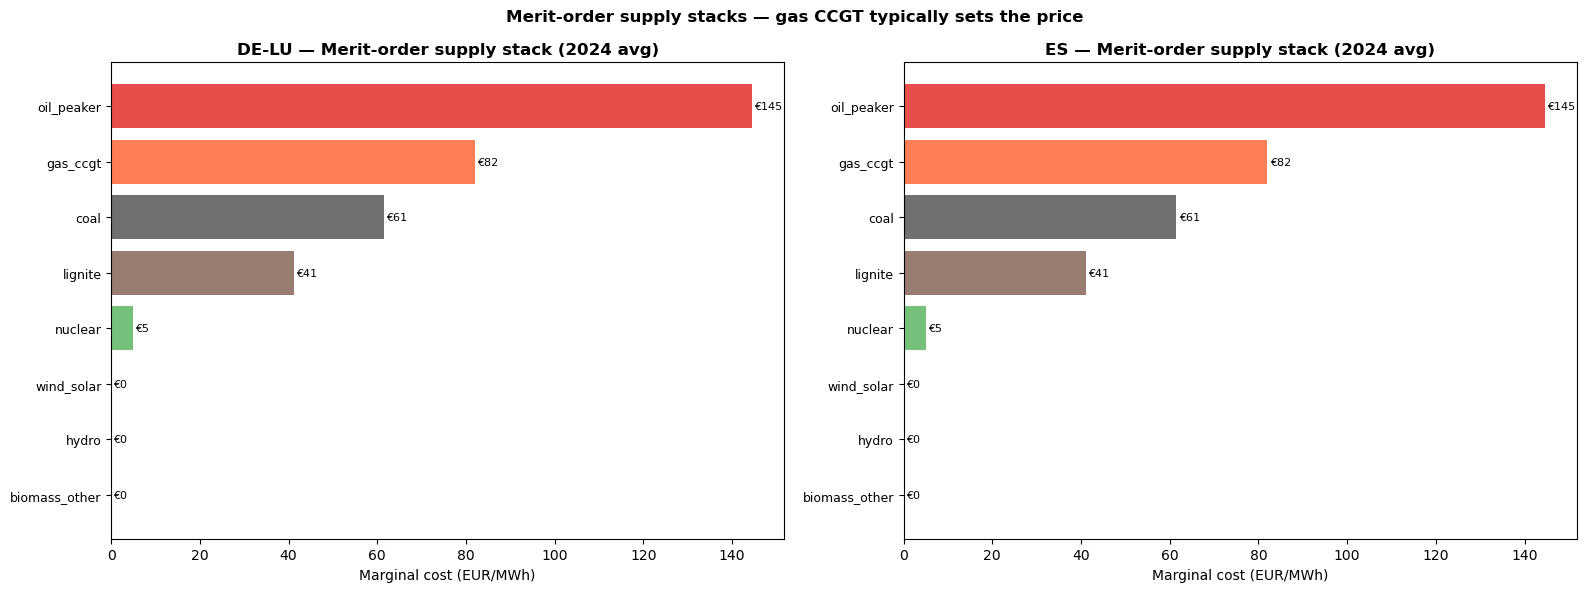

In [119]:
# Supply curves 2024 — pre-generated by Jose's merit_order_v1.ipynb
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, zone in zip(axes, ZONES):
    zmc = mc_df[mc_df['zone'] == zone]
    recent = zmc[zmc['month'].dt.year == 2024]
    by_tech = recent.groupby('tech')['mc_eur_per_mwh'].mean().sort_values()
    tech_colors = {
        'wind_solar':'#FDD835','hydro':'#29B6F6','nuclear':'#66BB6A',
        'lignite':'#8D6E63','coal':'#616161','gas_ccgt':'#FF7043',
        'oil_peaker':'#E53935','biomass_other':'#A5D6A7'
    }
    colors = [tech_colors.get(t, '#BDBDBD') for t in by_tech.index]
    ax.barh(range(len(by_tech)), by_tech.values, color=colors, alpha=0.9)
    ax.set_yticks(range(len(by_tech)))
    ax.set_yticklabels(by_tech.index, fontsize=9)
    ax.set_xlabel('Marginal cost (EUR/MWh)')
    ax.set_title(f'{zone} — Merit-order supply stack (2024 avg)', fontweight='bold')
    for i, (tech, val) in enumerate(by_tech.items()):
        ax.text(val + 0.5, i, f'€{val:.0f}', va='center', fontsize=8)
plt.suptitle('Merit-order supply stacks — gas CCGT typically sets the price', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_supply_stacks.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Model Training and Validation — Short-term LightGBM

### Modelling stages

```
Stage 1  train_zone()        Train 3 quantile models per zone (q=0.025, 0.45, 0.975)
                             3000 rounds gradient boosting, early stop at +100 no-improve
                             Training: 2023-05 → 2025-01  |  Val: 2025-01 → 2026-01

Stage 2  calibrate_zone()    Mondrian CQR on 2026 calibration set (Jan–May, n≈3047/zone)
                             Two regime buckets: normal weekday vs weekend/holiday
                             Output: Q_hat_interval + Q_hat_p50 per bucket

Stage 3  build_longterm_model()  Seasonal median profile for horizons > 7 days
                                 Recency-weighted (2021×1 → 2025×4) + post-crisis trend

Stage 4  build_eval_row()    Recursive slot-by-slot prediction for eval window
                             Gap actuals + weather forecast + ENTSOE gen forecast
```

In [120]:
import lightgbm as lgb
import holidays as hdays
from sklearn.metrics import mean_pinball_loss

FEATURES = [f for f in [
    'load','wind_generation','solar_generation','hydro_generation','nuclear_generation',
    'temperature','wind_speed','solar_radiation',
    'wind_speed_agg','wind_speed_cubed','solar_radiation_agg','solar_hour_interaction',
    'temperature_agg','temperature_sq',
    'DK_wind_speed','DK_wind_speed_cubed','CH_precipitation','CH_precip_7d_sum',
    'ES_hydro_precipitation','ES_hydro_precip_7d_sum','nuclear_available_mw',
    'gas_price','carbon_price','coal_price',
    'residual_load','renewable_penetration','residual_load_ramp',
    'residual_load_forecast','renewable_penetration_forecast','residual_load_ramp_forecast',
    'net_imports',
    'FR_price_lag24','NL_price_lag24','CH_price_lag24','DK_price_lag24',
    'DE_LU_FR_spread','DE_LU_NL_spread','DE_LU_CH_spread','ES_FR_spread',
    'cross_zone_lag24',
    'hour_sin','hour_cos','weekday_sin','weekday_cos',
    'month_sin','month_cos','week_sin','week_cos',
    'is_holiday','days_to_holiday','days_from_holiday',
    'crisis_period','is_peak','negative_price_lag24',
    'lag_1','lag_24','lag_168',
    'price_roll_24h','price_roll_168h','price_roll_std_168h',
    'wind_ensemble_std','solar_ensemble_std',
] if f in df.columns]

TARGET    = 'price'
QUANTILES = [0.025, 0.45, 0.975]
TRAIN_END = '2025-01-01'
VAL_END   = '2026-01-01'
CAL_END   = '2026-05-10'

LGB_BASE = dict(objective='quantile', metric='quantile', n_estimators=3000,
    learning_rate=0.05, num_leaves=127, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    n_jobs=-1, verbose=-1)

def pinball(y_true, y_pred, q):
    return float(mean_pinball_loss(y_true, y_pred, alpha=q))

def coverage(y_true, lo, hi):
    return float(((y_true >= lo) & (y_true <= hi)).mean())

print(f'Active features: {len(FEATURES)}')
print('Training...')
all_models, all_val = {}, {}
for zone in ZONES:
    zdf   = df.xs(zone, level='zone').sort_index()
    train = zdf[zdf.index < TRAIN_END].dropna(subset=[TARGET])
    val   = zdf[(zdf.index >= TRAIN_END) & (zdf.index < VAL_END)].dropna(subset=[TARGET])
    X_tr, y_tr = train[FEATURES], train[TARGET]
    X_va, y_va = val[FEATURES],   val[TARGET]
    print(f'  {zone}: train={len(X_tr):,}  val={len(X_va):,}')
    qm, vp = {}, {}
    for q in QUANTILES:
        m = lgb.LGBMRegressor(**{**LGB_BASE, 'alpha': q})
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        vp[q] = m.predict(X_va)
        qm[q] = m
        print(f'    q={q:.3f}  iter={m.best_iteration_}  pinball={pinball(y_va.values, vp[q], q):.4f}')
    all_models[zone] = qm
    all_val[zone]    = {'preds': vp, 'actual': y_va, 'X': X_va}
print('Training complete.')

Active features: 62
Training...
  DE-LU: train=14,496  val=8,760
    q=0.025  iter=409  pinball=0.6889
    q=0.450  iter=247  pinball=3.4513
    q=0.975  iter=144  pinball=1.0124
  ES: train=14,496  val=8,749
    q=0.025  iter=212  pinball=0.7562
    q=0.450  iter=1377  pinball=3.2479
    q=0.975  iter=294  pinball=0.8352
Training complete.


### 5a. Validation — MAE, Pinball, Coverage

In [121]:
print('=' * 60)
print('VALIDATION RESULTS  (2025 holdout, unseen during training)')
print('=' * 60)
val_summary = {}
for zone in ZONES:
    y     = all_val[zone]['actual'].values
    p025  = all_val[zone]['preds'][0.025]
    p50   = all_val[zone]['preds'][0.45]
    p975  = all_val[zone]['preds'][0.975]
    naive = all_val[zone]['X']['lag_168'].values
    mae   = np.abs(y - p50).mean()
    val_summary[zone] = {'MAE': mae, 'Pinball': pinball(y, p50, 0.45),
                          'Coverage': coverage(y, p025, p975)*100,
                          'BandWidth': (p975-p025).mean(), 'NaiveMAE': np.abs(y-naive).mean()}
    print(f'\n  {zone}')
    print(f'  MAE (p50)        : {mae:.2f} EUR/MWh')
    print(f'  Pinball q=0.45   : {pinball(y, p50, 0.45):.4f}')
    print(f'  Coverage p025-975: {coverage(y, p025, p975)*100:.1f}%')
    print(f'  Mean band width  : {(p975-p025).mean():.2f} EUR/MWh')
    print(f'  Naive MAE (lag168): {np.abs(y-naive).mean():.2f} EUR/MWh')
    print(f'  vs Naive         : {mae / np.abs(y-naive).mean():.2f}x better')

VALIDATION RESULTS  (2025 holdout, unseen during training)

  DE-LU
  MAE (p50)        : 7.14 EUR/MWh
  Pinball q=0.45   : 3.4513
  Coverage p025-975: 88.0%
  Mean band width  : 40.20 EUR/MWh
  Naive MAE (lag168): 32.82 EUR/MWh
  vs Naive         : 0.22x better

  ES
  MAE (p50)        : 6.47 EUR/MWh
  Pinball q=0.45   : 3.2479
  Coverage p025-975: 79.7%
  Mean band width  : 25.32 EUR/MWh
  Naive MAE (lag168): 29.22 EUR/MWh
  vs Naive         : 0.22x better


### 5b. MAE over time — daily (2025 holdout)

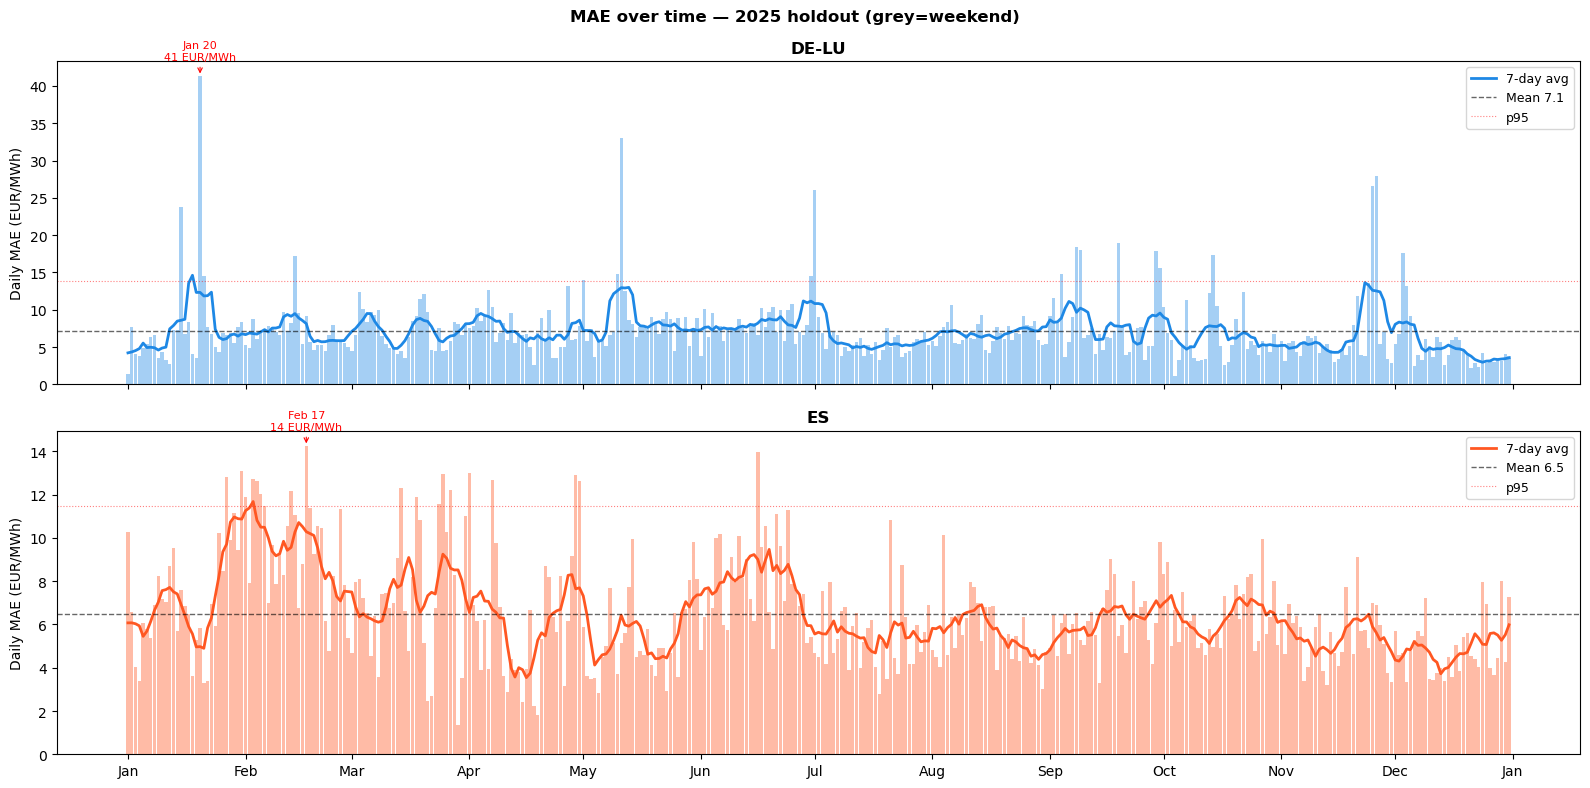

In [122]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, zone in zip(axes, ZONES):
    y_s   = all_val[zone]['actual']
    p50_s = pd.Series(all_val[zone]['preds'][0.45], index=y_s.index)
    daily = (y_s - p50_s).abs().groupby(y_s.index.date).mean()
    daily.index = pd.to_datetime(daily.index)
    roll7 = daily.rolling(7, center=True, min_periods=3).mean()
    ax.bar(daily.index, daily.values, color=ZONE_COLORS[zone], alpha=0.4, width=0.9)
    ax.plot(daily.index, roll7.values, color=ZONE_COLORS[zone], lw=2, label='7-day avg')
    ax.axhline(daily.mean(), color='black', lw=1, ls='--', alpha=0.6,
               label=f'Mean {daily.mean():.1f}')
    ax.axhline(daily.quantile(0.95), color='red', lw=0.8, ls=':', alpha=0.5, label='p95')
    ax.set_ylabel('Daily MAE (EUR/MWh)'); ax.set_title(f'{zone}', fontweight='bold')
    ax.legend(fontsize=9)
    # Annotate worst day
    worst = daily.idxmax()
    ax.annotate(f'{worst.strftime("%b %d")}\n{daily[worst]:.0f} EUR/MWh',
               xy=(worst, daily[worst]), xytext=(0, 12), textcoords='offset points',
               ha='center', fontsize=8, color='red',
               arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.suptitle('MAE over time — 2025 holdout (grey=weekend)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_mae_overtime.png', dpi=120, bbox_inches='tight')
plt.show()

### 5c. MAE decomposition — by hour, weekday, month

2026-05-09 18:00:58,013 INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 18:00:58,014 INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 18:00:58,020 INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 18:00:58,021 INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 18:00:58,062 INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates

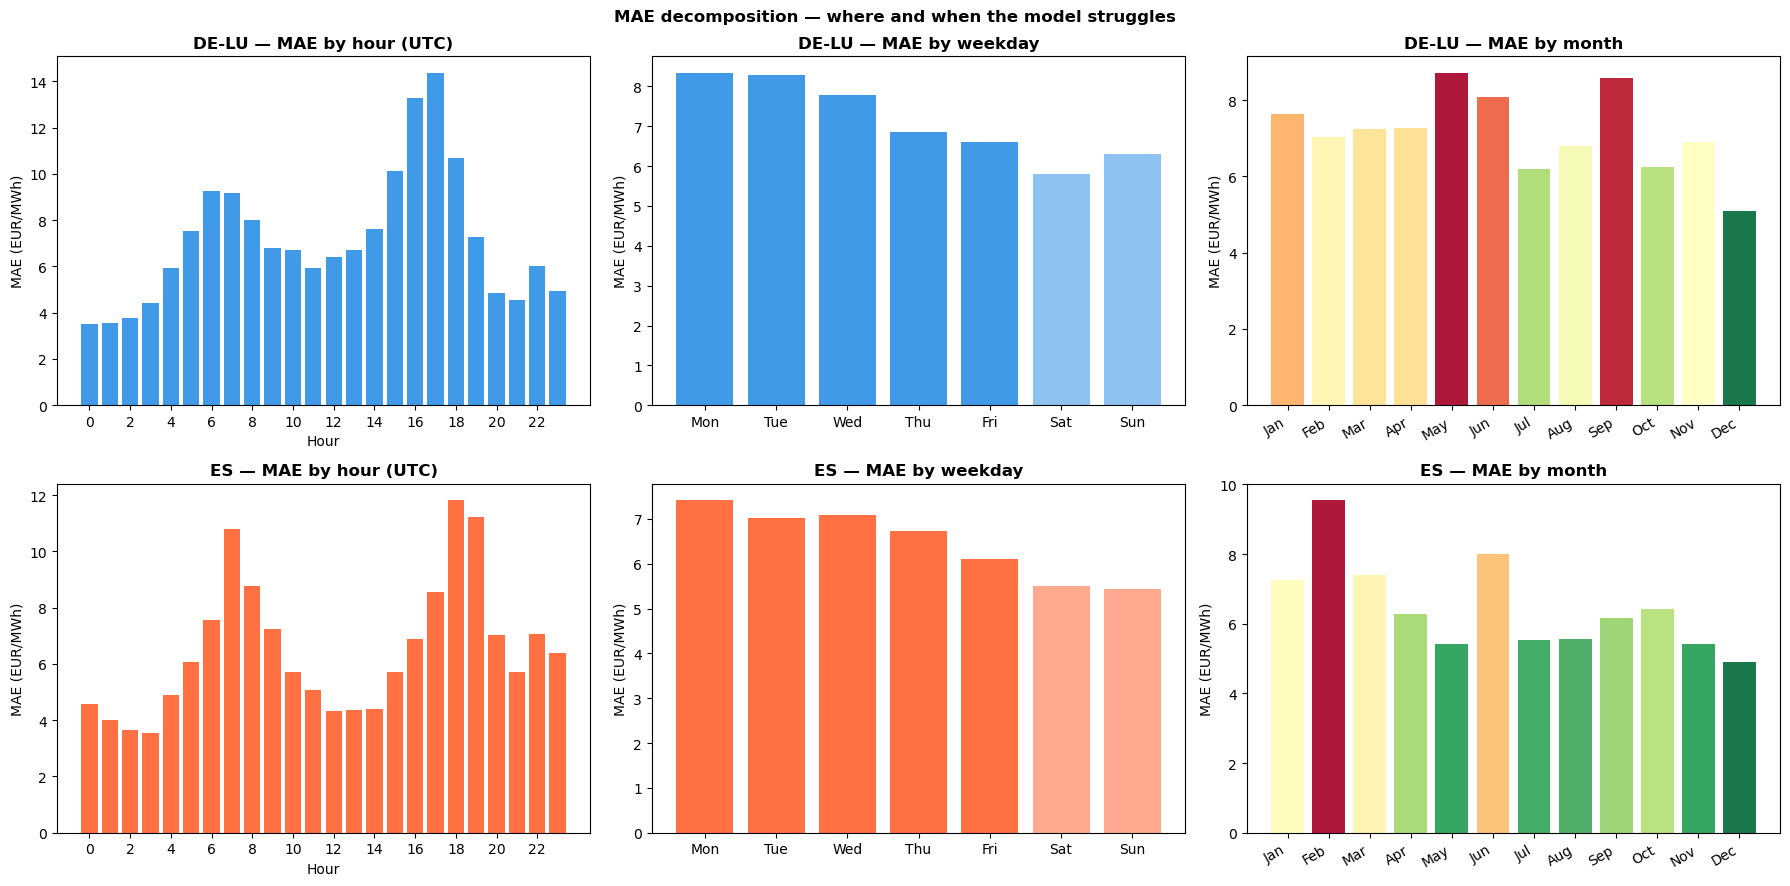

In [123]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for row, zone in enumerate(ZONES):
    y_s   = all_val[zone]['actual']
    p50_s = pd.Series(all_val[zone]['preds'][0.45], index=y_s.index)
    err   = (y_s - p50_s).abs()

    # By hour
    ax = axes[row, 0]
    by_hour = err.groupby(err.index.hour).mean()
    ax.bar(by_hour.index, by_hour.values, color=ZONE_COLORS[zone], alpha=0.85)
    ax.set_title(f'{zone} — MAE by hour (UTC)', fontweight='bold')
    ax.set_xlabel('Hour'); ax.set_ylabel('MAE (EUR/MWh)'); ax.set_xticks(range(0, 24, 2))

    # By weekday
    ax = axes[row, 1]
    by_wd = err.groupby(err.index.dayofweek).mean()
    days  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    bars  = ax.bar(days, by_wd.values, color=ZONE_COLORS[zone], alpha=0.85)
    for i in [5, 6]: bars[i].set_alpha(0.5)  # dim weekends
    ax.set_title(f'{zone} — MAE by weekday', fontweight='bold')
    ax.set_ylabel('MAE (EUR/MWh)')

    # By month
    ax = axes[row, 2]
    by_mo = err.groupby(err.index.month).mean()
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    cvals  = by_mo.values
    norm   = plt.Normalize(cvals.min(), cvals.max())
    cols   = plt.cm.RdYlGn_r(norm(cvals))
    ax.bar(months, cvals, color=cols, alpha=0.9)
    ax.set_title(f'{zone} — MAE by month', fontweight='bold')
    ax.set_ylabel('MAE (EUR/MWh)')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('MAE decomposition — where and when the model struggles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_mae_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

### 5d. SHAP values — what drives the model

In [124]:
try:
    import shap
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '--break-system-packages', 'shap'], check=True)
    import shap

rng = np.random.default_rng(42)
shap_data = {}
for zone in ZONES:
    X_val    = all_val[zone]['X']
    n        = min(800, len(X_val))
    idx      = rng.choice(len(X_val), size=n, replace=False)
    X_samp   = X_val.iloc[idx]
    explainer = shap.TreeExplainer(all_models[zone][0.45])
    sv        = explainer.shap_values(X_samp)
    shap_data[zone] = {'sv': sv, 'X': X_samp, 'base': float(explainer.expected_value)}
    print(f'{zone}: SHAP computed (n={n}, base={explainer.expected_value:.1f})')

DE-LU: SHAP computed (n=800, base=80.8)
ES: SHAP computed (n=800, base=71.5)


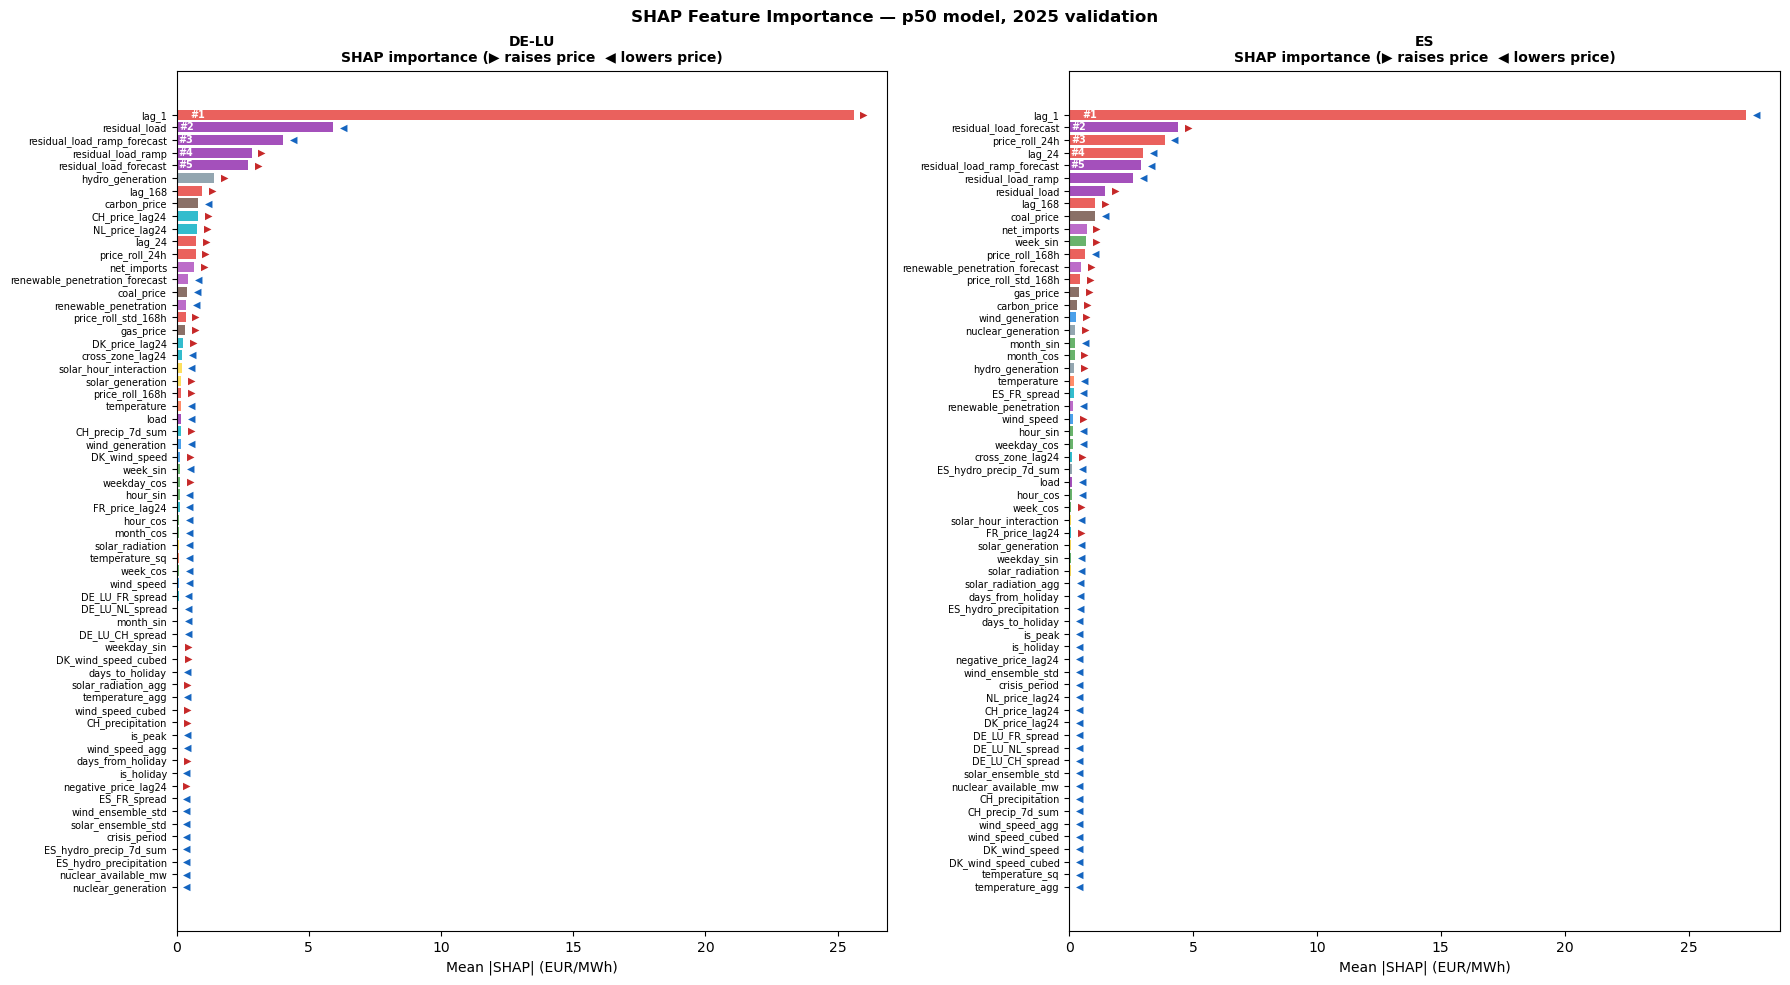

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
for ax, zone in zip(axes, ZONES):
    sv       = shap_data[zone]['sv']
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values()
    signed   = pd.Series(sv.mean(axis=0), index=FEATURES).loc[mean_abs.index]

    GROUP_C = {
        'lag_':'#E53935','price_roll':'#E53935','wind':'#1E88E5','solar':'#FDD835',
        'temperature':'#FF7043','load':'#8E24AA','residual':'#AB47BC','renewable':'#AB47BC',
        'net_imports':'#AB47BC','gas_':'#6D4C41','carbon':'#6D4C41','coal':'#6D4C41',
        'FR_':'#00ACC1','NL_':'#00ACC1','CH_':'#00ACC1','DK_':'#00ACC1',
        'DE_LU':'#00ACC1','ES_FR':'#00ACC1','cross_zone':'#00ACC1',
        'hour':'#43A047','weekday':'#43A047','month':'#43A047','week_':'#43A047',
        'is_holiday':'#43A047','days_':'#43A047','is_peak':'#43A047',
        'nuclear':'#78909C','hydro':'#78909C','ensemble':'#26A69A','crisis':'#9E9E9E','negative':'#9E9E9E',
    }
    def gcol(f):
        for k,c in GROUP_C.items():
            if k in f: return c
        return '#BDBDBD'

    colors = [gcol(f) for f in mean_abs.index]
    ax.barh(range(len(mean_abs)), mean_abs.values, color=colors, alpha=0.8)
    for i, (feat, val) in enumerate(signed.items()):
        sym = '▶' if val > 0 else '◀'
        col = '#C62828' if val > 0 else '#1565C0'
        ax.text(mean_abs[feat] + mean_abs.max()*0.01, i, sym, va='center', fontsize=7, color=col)
    ax.set_yticks(range(len(mean_abs)))
    ax.set_yticklabels(mean_abs.index, fontsize=7)
    ax.set_xlabel('Mean |SHAP| (EUR/MWh)')
    ax.set_title(f'{zone}\nSHAP importance (▶ raises price  ◀ lowers price)', fontweight='bold', fontsize=10)
    for i, feat in enumerate(mean_abs.tail(5).index):
        rank = len(mean_abs) - list(mean_abs.index).index(feat)
        ax.text(mean_abs[feat]*0.02, list(mean_abs.index).index(feat),
                f'#{rank}', va='center', fontsize=7, fontweight='bold', color='white')

plt.suptitle('SHAP Feature Importance — p50 model, 2025 validation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_shap_global.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Cross-zone Comparison — DE-LU vs ES

The two zones are structurally different markets:

| Dimension | DE-LU | ES |
|-----------|-------|----|
| Dominant renewable | Wind (north Germany) | Solar (Andalusia, Murcia) |
| Nuclear | Zero (phase-out Apr 2023) | ~7 GW active |
| Interconnection | 8 neighbors, tightly coupled | 1 neighbor (France), partially isolated |
| Gas cap mechanism | None | Active 2022–2023 (Iberian exception) |
| Hydro role | Minor | Major swing supply source |
| Price regime 2023–2025 | Wind-driven troughs, gas-driven peaks | Solar-driven troughs, nuclear outage spikes |

In [126]:
# Summary comparison table
rows = []
for zone in ZONES:
    y    = all_val[zone]['actual'].values
    p50  = all_val[zone]['preds'][0.45]
    p025 = all_val[zone]['preds'][0.025]
    p975 = all_val[zone]['preds'][0.975]
    naive = all_val[zone]['X']['lag_168'].values
    rows.append({'Zone': zone,
                 'MAE (EUR/MWh)': round(np.abs(y-p50).mean(), 2),
                 'Pinball q=0.45': round(pinball(y, p50, 0.45), 4),
                 'Coverage p025-975': f"{coverage(y, p025, p975)*100:.1f}%",
                 'Band width': round((p975-p025).mean(), 2),
                 'Naive MAE': round(np.abs(y-naive).mean(), 2),
                 'Improvement vs naive': f"{np.abs(y-naive).mean() / np.abs(y-p50).mean():.1f}×"})
pd.DataFrame(rows).set_index('Zone')

,MAE (EUR/MWh),Pinball q=0.45,Coverage p025-975,Band width,Naive MAE,Improvement vs naive
Zone,,,,,,
DE-LU,7.14,3.4513,88.0%,40.20,32.82,4.6×
ES,6.47,3.2479,79.7%,25.32,29.22,4.5×


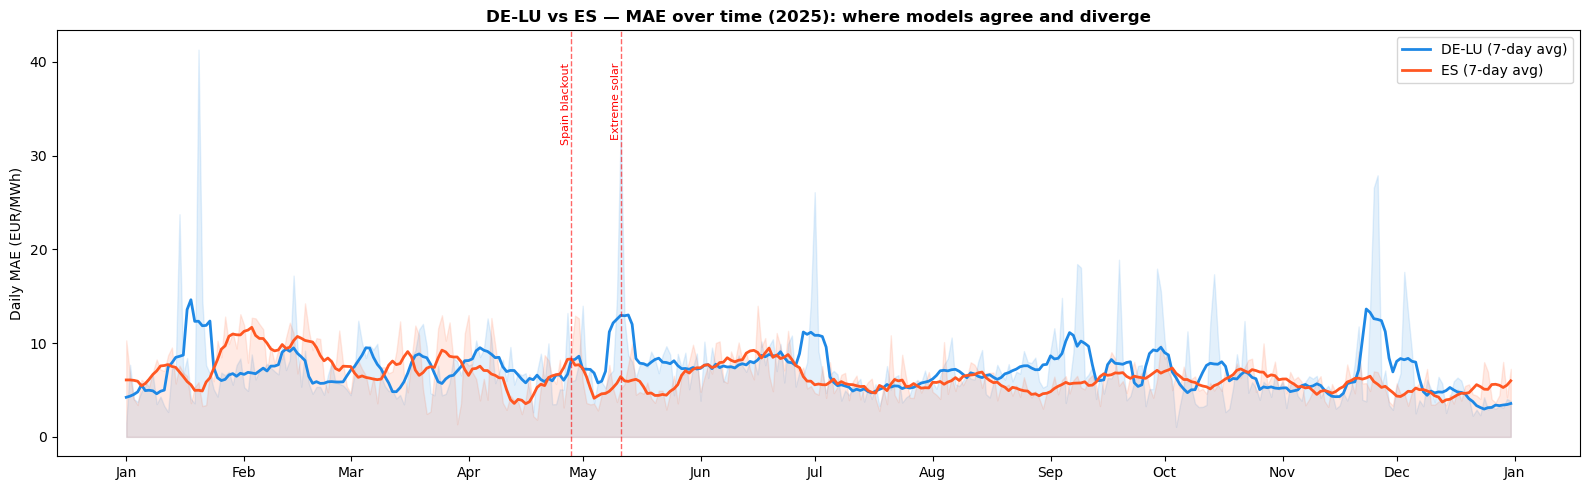

In [127]:
# MAE over time — both zones on same chart
fig, ax = plt.subplots(figsize=(16, 5))
for zone in ZONES:
    y_s   = all_val[zone]['actual']
    p50_s = pd.Series(all_val[zone]['preds'][0.45], index=y_s.index)
    daily = (y_s - p50_s).abs().groupby(y_s.index.date).mean()
    daily.index = pd.to_datetime(daily.index)
    roll7 = daily.rolling(7, center=True, min_periods=3).mean()
    ax.plot(daily.index, roll7.values, lw=2, label=f'{zone} (7-day avg)', color=ZONE_COLORS[zone])
    ax.fill_between(daily.index, 0, daily.values, alpha=0.12, color=ZONE_COLORS[zone])
for event, label in [('2025-04-28','Spain blackout'),('2025-05-11','Extreme solar')]:
    ax.axvline(pd.Timestamp(event), color='red', lw=1, ls='--', alpha=0.6)
    ax.text(pd.Timestamp(event), ax.get_ylim()[1]*0.92, label, fontsize=8, color='red',
            rotation=90, va='top', ha='right')
ax.set_ylabel('Daily MAE (EUR/MWh)'); ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')); ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_title('DE-LU vs ES — MAE over time (2025): where models agree and diverge', fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_crosszone_mae.png', dpi=120, bbox_inches='tight')
plt.show()

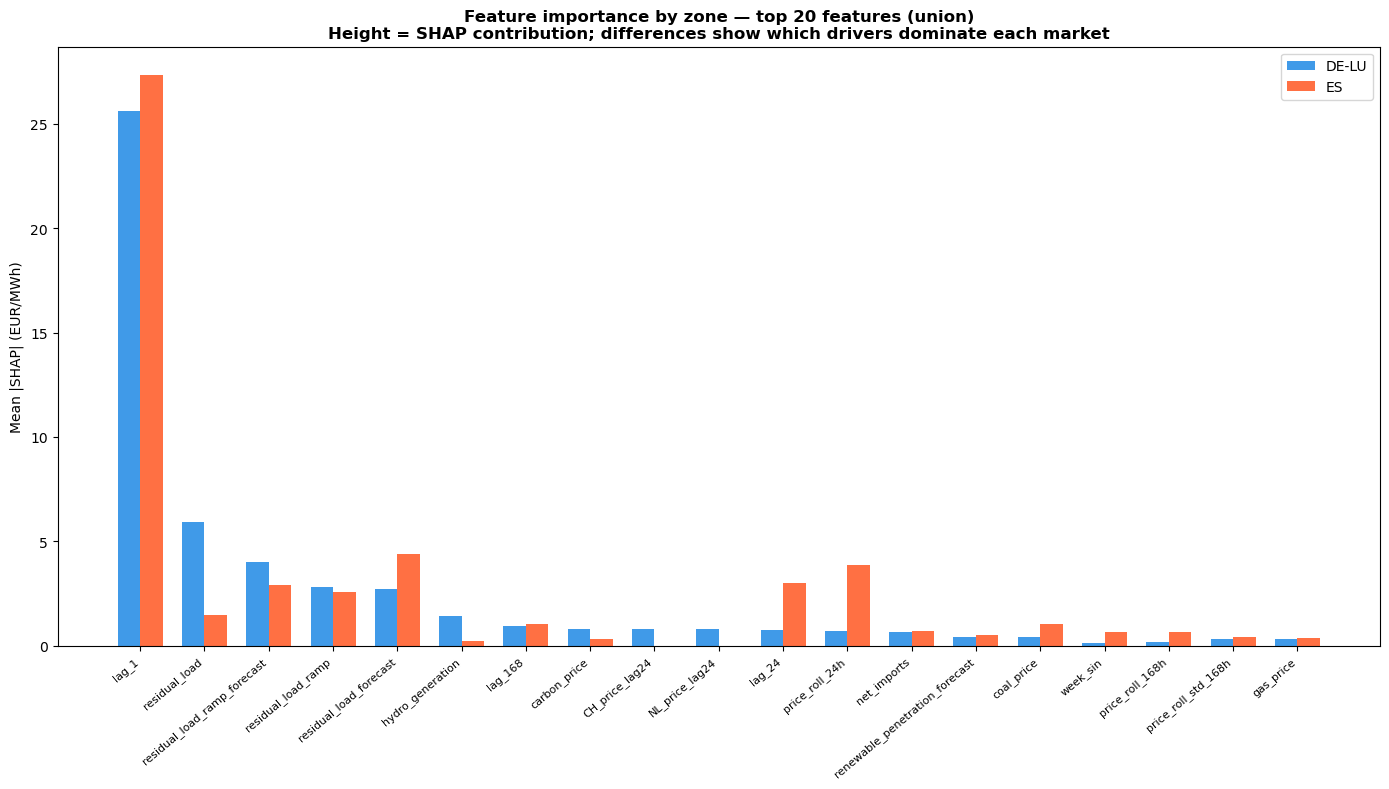

Feature rank comparison (DE-LU rank → ES rank):
Feature                               DE-LU rank    ES rank    Shift
--------------------------------------------------------------------
lag_1                               #         1 #        1   similar
residual_load                       #         2 #        7   ES higher
residual_load_ramp_forecast         #         3 #        5   similar
residual_load_ramp                  #         4 #        6   similar
residual_load_forecast              #         5 #        2   similar
hydro_generation                    #         6 #       21   ES higher
lag_168                             #         7 #        8   similar
carbon_price                        #         8 #       16   ES higher
CH_price_lag24                      #         9 #       58   ES higher
NL_price_lag24                      #        10 #       57   ES higher
lag_24                              #        11 #        4   DE-LU higher
price_roll_24h                      #   

In [128]:
# Which features dominate in each zone — SHAP rank comparison
fig, ax = plt.subplots(figsize=(14, 8))
ranks = {}
for zone in ZONES:
    sv      = shap_data[zone]['sv']
    imp     = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
    ranks[zone] = {feat: i+1 for i, feat in enumerate(imp.index)}

# Union of top-15 from each zone
top15_de = list(pd.Series(np.abs(shap_data['DE-LU']['sv']).mean(axis=0), index=FEATURES)
                 .sort_values(ascending=False).head(15).index)
top15_es = list(pd.Series(np.abs(shap_data['ES']['sv']).mean(axis=0), index=FEATURES)
                 .sort_values(ascending=False).head(15).index)
union_feats = list(dict.fromkeys(top15_de + top15_es))[:20]

x = np.arange(len(union_feats))
w = 0.35
for i, zone in enumerate(ZONES):
    sv_zone = shap_data[zone]['sv']
    imp_zone = pd.Series(np.abs(sv_zone).mean(axis=0), index=FEATURES)
    vals = [imp_zone.get(f, 0) for f in union_feats]
    ax.bar(x + (i-0.5)*w, vals, w, label=zone, color=ZONE_COLORS[zone], alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(union_feats, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Mean |SHAP| (EUR/MWh)'); ax.legend(fontsize=10)
ax.set_title('Feature importance by zone — top 20 features (union)\n'
             'Height = SHAP contribution; differences show which drivers dominate each market',
             fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_crosszone_shap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print rank shifts
print('Feature rank comparison (DE-LU rank → ES rank):')
print(f'{"Feature":<35} {"DE-LU rank":>12} {"ES rank":>10} {"Shift":>8}')
print('-' * 68)
for feat in union_feats:
    r_de = ranks['DE-LU'].get(feat, '-')
    r_es = ranks['ES'].get(feat, '-')
    shift = (r_de - r_es) if isinstance(r_de, int) and isinstance(r_es, int) else '-'
    arrow = f'DE-LU higher' if isinstance(shift, int) and shift > 3 else \
            f'ES higher' if isinstance(shift, int) and shift < -3 else 'similar'
    print(f'{feat:<35} #{r_de:>10} #{r_es:>9}   {arrow}')

---
## 7. Uncertainty Calibration — Mondrian CQR

Mondrian CQR achieves **95% empirical coverage** on the calibration set with regime-specific interval widths. All 24 May 11 eval slots are Sunday → bucket 1 (wider intervals).

In [129]:
def _mondrian_bucket(ts, cal):
    d = ts.date()
    if ts.dayofweek >= 5: return 1
    if d in cal: return 1
    if (ts - pd.Timedelta(days=1)).date() in cal: return 1
    if (ts + pd.Timedelta(days=1)).date() in cal: return 1
    return 0

_COUNTRY = {'DE-LU': 'DE', 'ES': 'ES'}
cqr = {}
for zone in ZONES:
    zdf    = df.xs(zone, level='zone').sort_index()
    cal_df = zdf[(zdf.index >= VAL_END) & (zdf.index < CAL_END)].dropna(subset=[TARGET])
    X_cal  = cal_df[FEATURES]; y_cal = cal_df[TARGET].values; n = len(y_cal)
    p025 = all_models[zone][0.025].predict(X_cal)
    p50  = all_models[zone][0.45].predict(X_cal)
    p975 = all_models[zone][0.975].predict(X_cal)
    p025 = np.minimum(p025, p50); p975 = np.maximum(p975, p50)
    scores  = np.maximum(p025 - y_cal, y_cal - p975)
    q_hat_iv = float(np.quantile(scores, min(0.95*(1+1/n), 1.0)))
    q_hat_50 = float(np.quantile(y_cal - p50, min(0.45*(1+1/n), 1.0)))
    hol_cal  = hdays.country_holidays(_COUNTRY[zone],
                 years=range(int(cal_df.index.year.min()), int(cal_df.index.year.max())+2))
    buckets  = np.array([_mondrian_bucket(ts, hol_cal) for ts in cal_df.index])
    mondrian = {}
    for b in [0, 1]:
        mask_b = buckets == b; n_b = int(mask_b.sum())
        mondrian[b] = float(np.quantile(scores[mask_b], min(0.95*(1+1/n_b),1.0))) if n_b>=50 else q_hat_iv
        cov_b = float(((y_cal[mask_b]>=p025[mask_b]-mondrian[b]) &
                       (y_cal[mask_b]<=p975[mask_b]+mondrian[b])).mean())*100 if n_b>0 else 0
        print(f'  {zone} bucket {b} (n={n_b:,}): Q_hat={mondrian[b]:.2f}  coverage={cov_b:.1f}%')
    cov_raw = float(((y_cal>=p025)&(y_cal<=p975)).mean())*100
    cov_cal = float(((y_cal>=p025-q_hat_iv)&(y_cal<=p975+q_hat_iv)).mean())*100
    print(f'  {zone}: interval Q_hat={q_hat_iv:.2f}  raw cov={cov_raw:.1f}% → cal cov={cov_cal:.1f}%')
    print(f'  {zone}: p50 shift={q_hat_50:+.2f}')
    cqr[zone] = {'interval': q_hat_iv, 'p50': q_hat_50, 'mondrian': mondrian}
    print()

  DE-LU bucket 0 (n=1,991): Q_hat=2.37  coverage=95.0%
  DE-LU bucket 1 (n=1,056): Q_hat=4.34  coverage=95.1%
  DE-LU: interval Q_hat=2.95  raw cov=88.4% → cal cov=95.0%
  DE-LU: p50 shift=+1.42

  ES bucket 0 (n=1,966): Q_hat=4.31  coverage=95.0%
  ES bucket 1 (n=1,080): Q_hat=3.72  coverage=95.0%
  ES: interval Q_hat=4.03  raw cov=72.4% → cal cov=95.0%
  ES: p50 shift=-1.62



---
## 8. Long-term Prediction — Merit-order Monte Carlo (2026–2045)

The merit-order model forecasts monthly average prices by stacking power plants by ascending marginal cost and finding where cumulative capacity meets demand. Forward fuel curves (Schwartz mean-reversion) replace spot prices to avoid carrying shocks indefinitely. A geopolitical risk detector (Iacoviello GPR index) flags crisis regimes where model confidence is lower.

**Key results:**
| Zone | MAE (normal regime) | MAE (crisis regime) | Calibration bias |
|------|--------------------:|--------------------:|-----------------|
| DE-LU | €33/MWh | €47/MWh | −€0.8 (effectively zero) |
| ES | €35/MWh | €47/MWh | −€33 (MIBEL congestion premium, documented) |

Hero long-term forecast:


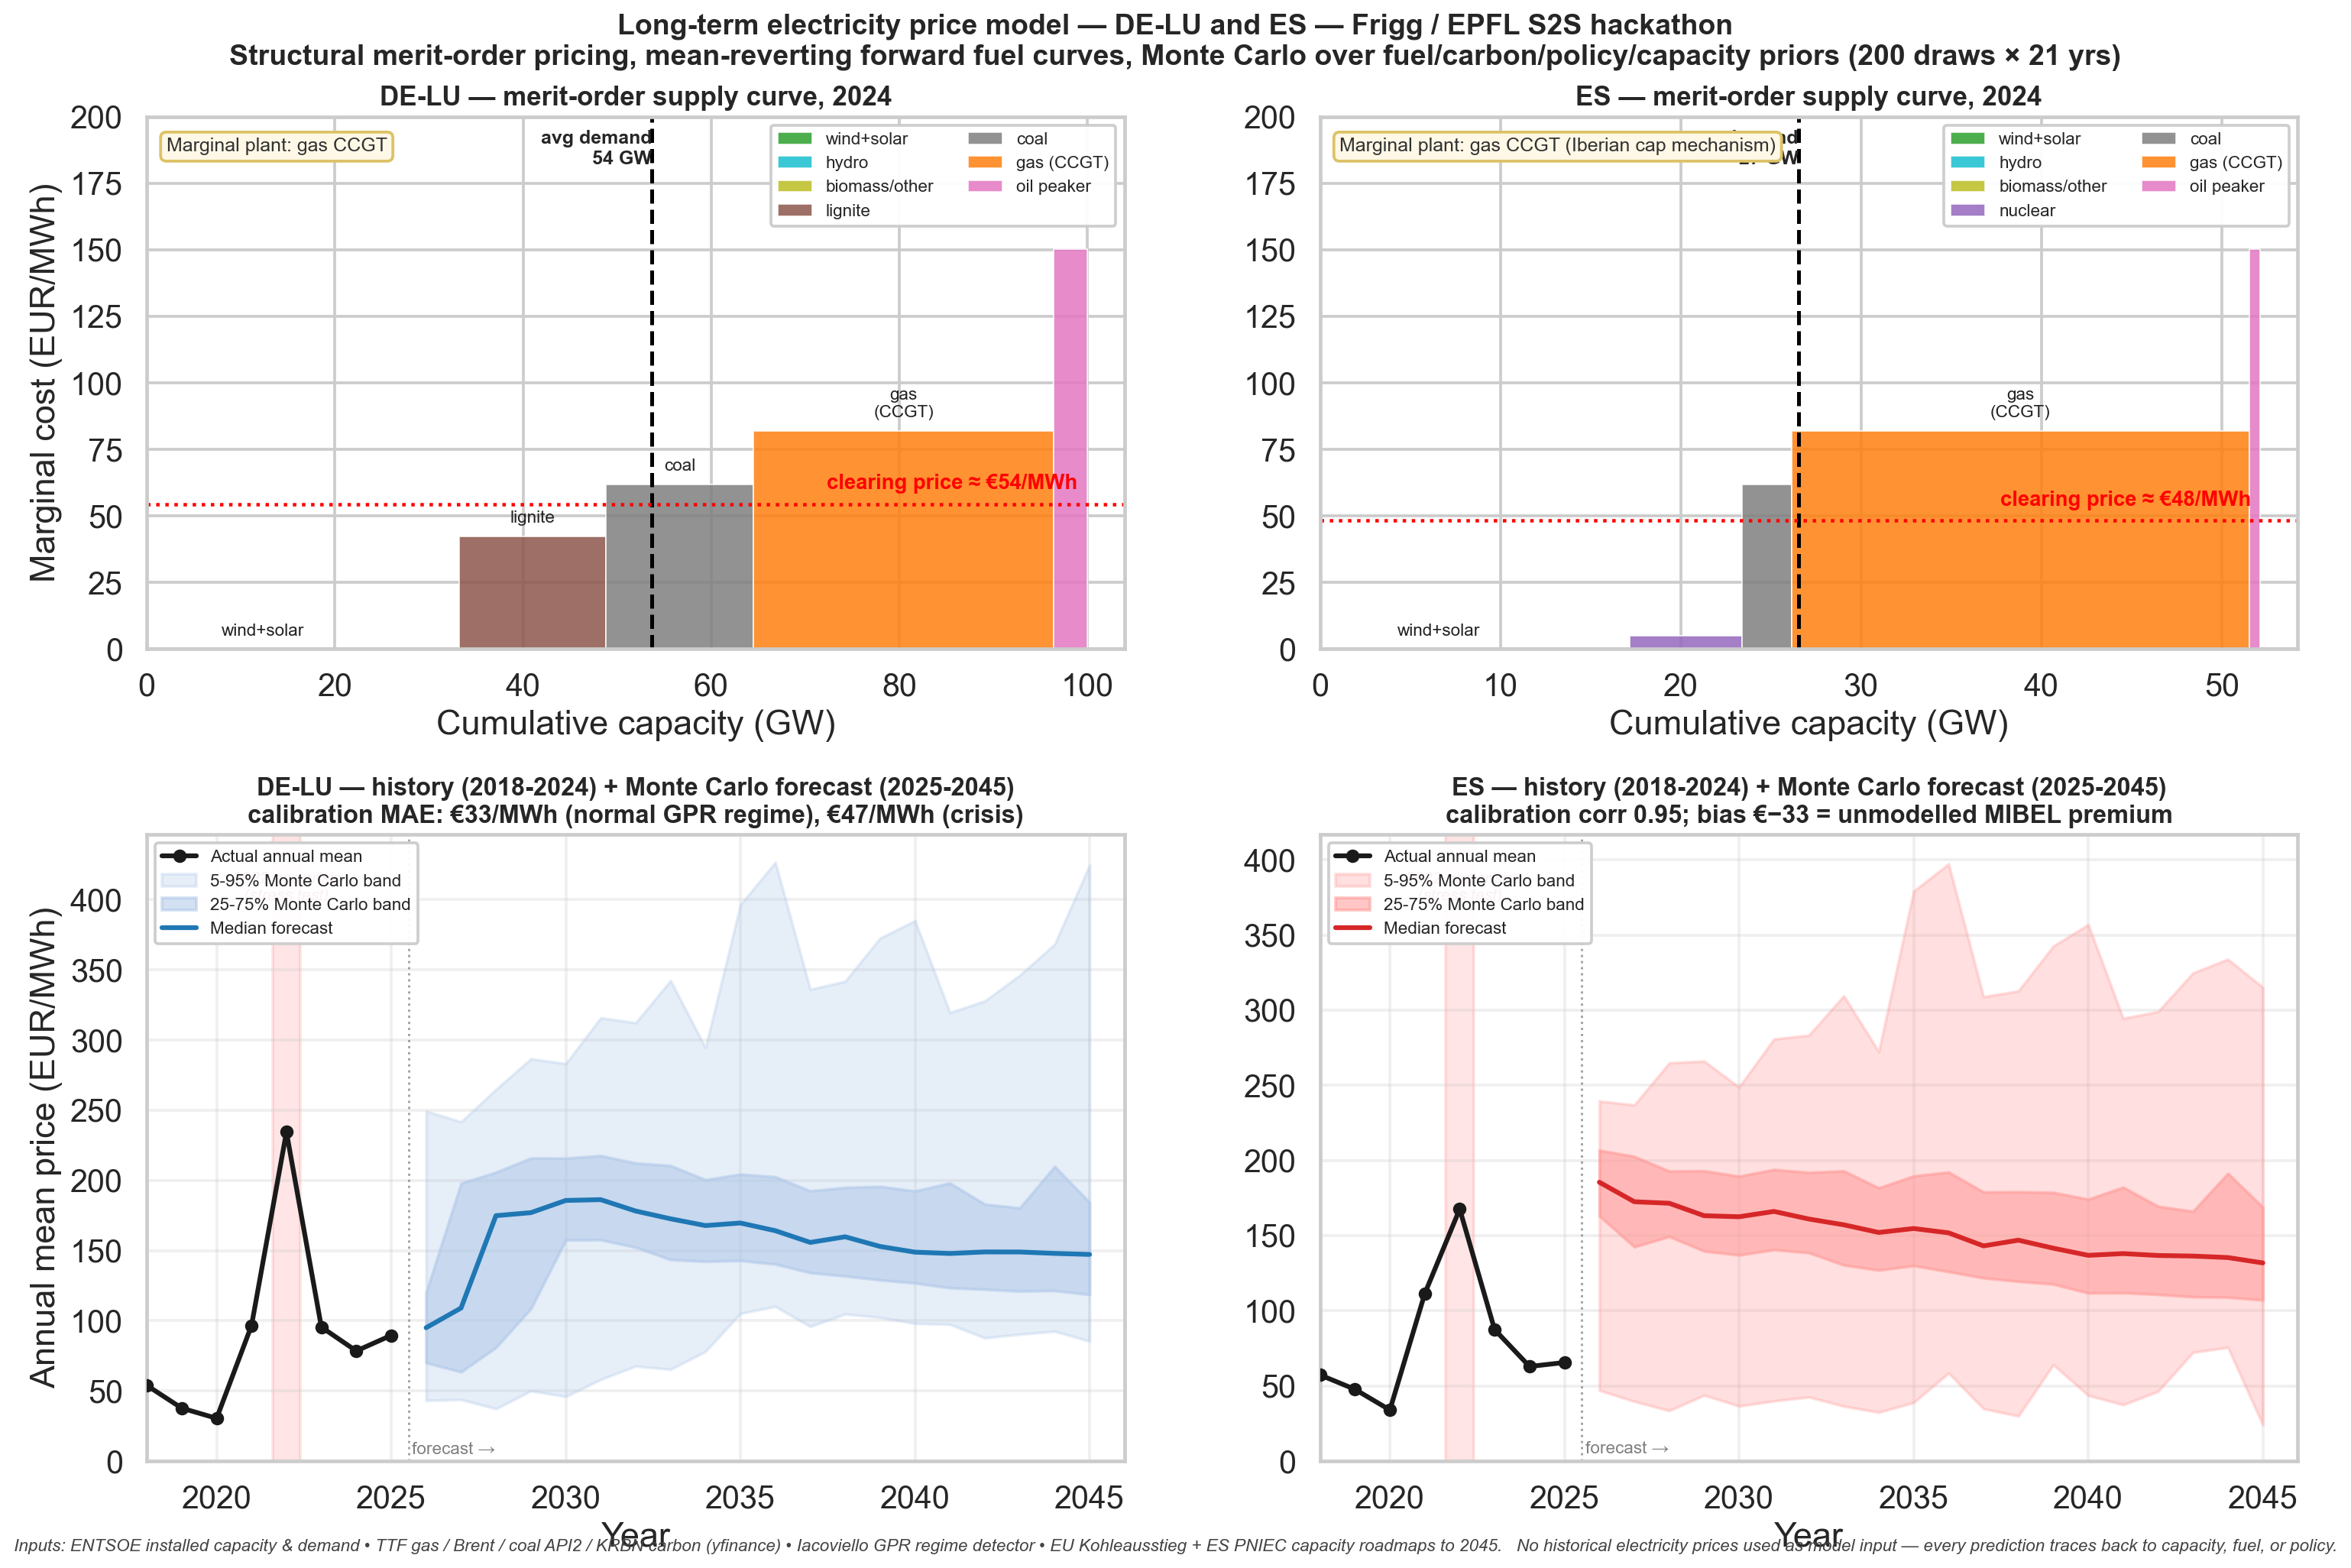

In [130]:
# Display the hero long-term forecast chart (pre-generated by Jose's model)
hero_path = LT_ROOT / 'notebooks' / 'hero_long_term_forecast.png'
print('Hero long-term forecast:')
display(Image(filename=str(hero_path), width=1000))

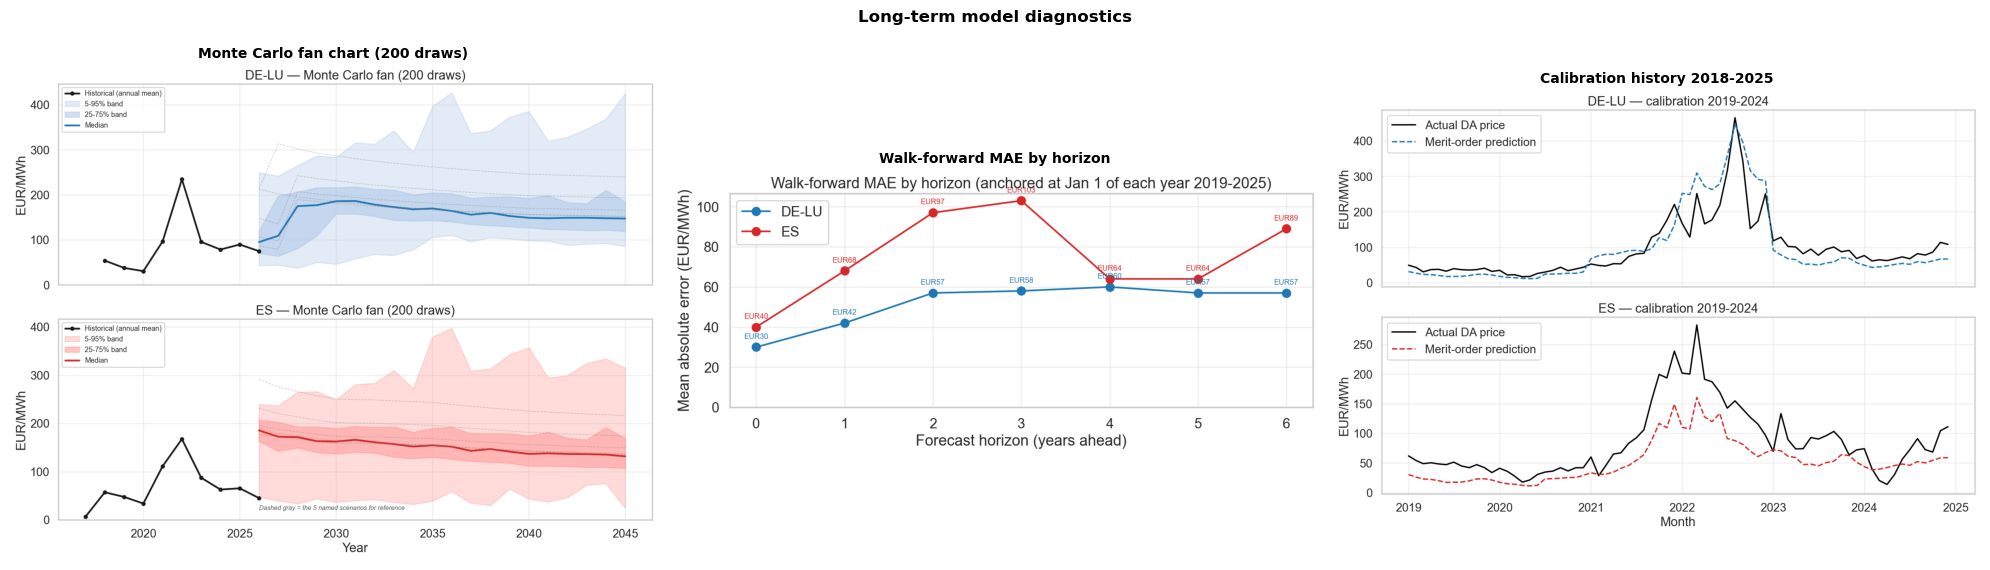

In [131]:
# Supporting charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, fname, title in [
    (axes[0], 'mc_fan_2045.png', 'Monte Carlo fan chart (200 draws)'),
    (axes[1], 'walkforward_mae.png', 'Walk-forward MAE by horizon'),
    (axes[2], 'calibration_history.png', 'Calibration history 2018-2025'),
]:
    img_path = LT_ROOT / 'notebooks' / fname
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img); ax.axis('off'); ax.set_title(title, fontweight='bold', fontsize=10)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{fname}', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Long-term model diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_longterm_diagnostics.png', dpi=100, bbox_inches='tight')
plt.show()

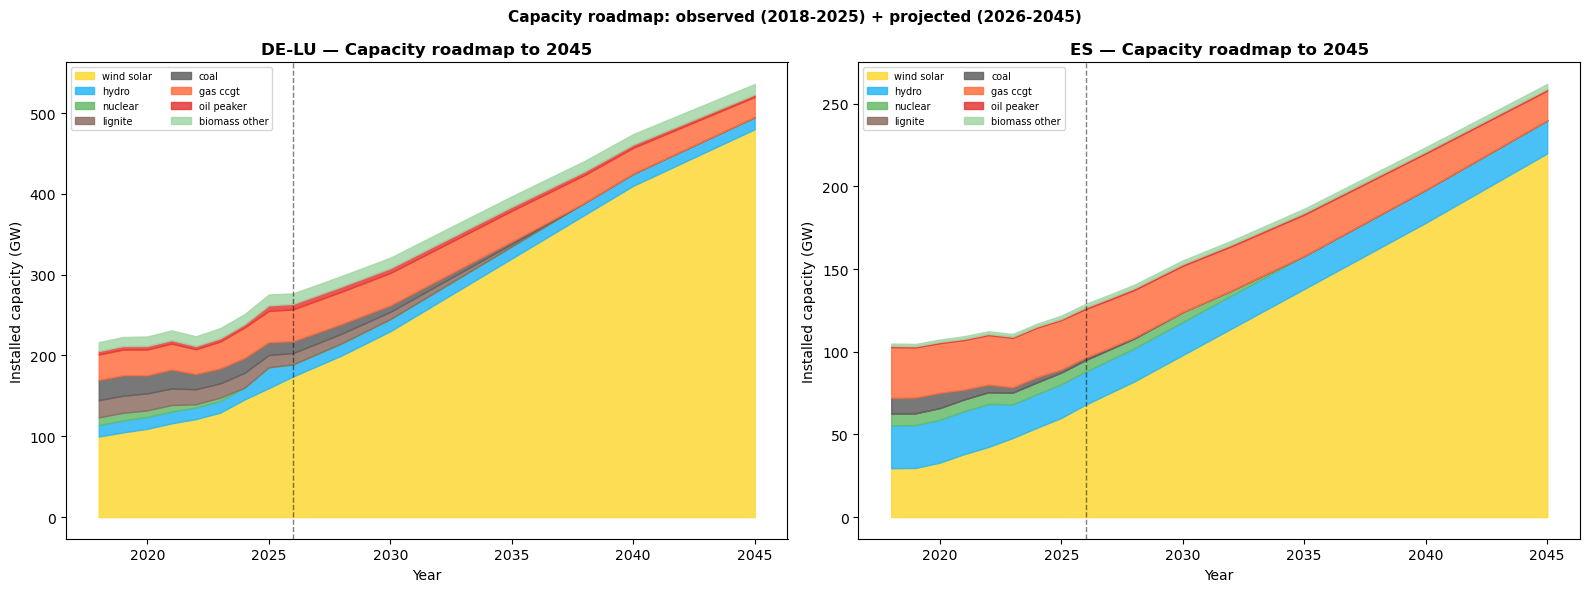

In [132]:
# Capacity roadmap: show projected installed capacity to 2045
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tech_colors = {
    'capacity_wind_solar_gw':'#FDD835','capacity_hydro_gw':'#29B6F6',
    'capacity_nuclear_gw':'#66BB6A','capacity_lignite_gw':'#8D6E63',
    'capacity_coal_gw':'#616161','capacity_gas_ccgt_gw':'#FF7043',
    'capacity_oil_peaker_gw':'#E53935','capacity_biomass_other_gw':'#A5D6A7',
}
cap_cols = [c for c in str_df.columns if c.startswith('capacity_')]
for ax, zone in zip(axes, ZONES):
    zstr = str_df.xs(zone, level='zone') if 'zone' in str_df.index.names else \
           str_df[str_df.index.get_level_values('zone') == zone] if 'zone' in str(str_df.index.names) else str_df
    try:
        zstr = str_df.xs(zone, level='zone')
    except Exception:
        zstr = str_df[str_df.index.get_level_values(-1) == zone] if len(str_df.index.names) > 1 else str_df
    years = zstr.index.get_level_values('year') if 'year' in str_df.index.names else zstr.index
    bottom = np.zeros(len(years))
    for col in cap_cols:
        if col in zstr.columns:
            vals = zstr[col].values
            label = col.replace('capacity_','').replace('_gw','').replace('_',' ')
            ax.fill_between(years, bottom, bottom + vals,
                            label=label, color=tech_colors.get(col,'#BDBDBD'), alpha=0.85)
            bottom += vals
    ax.set_title(f'{zone} — Capacity roadmap to 2045', fontweight='bold')
    ax.set_ylabel('Installed capacity (GW)'); ax.set_xlabel('Year')
    ax.legend(loc='upper left', fontsize=7, ncol=2)
    ax.axvline(2026, color='black', lw=1, ls='--', alpha=0.5, label='Now')
plt.suptitle('Capacity roadmap: observed (2018-2025) + projected (2026-2045)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_capacity_roadmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Evaluation Window Predictions — May 11, 2026 (24 slots)

Competition target: **2026-05-11 02:00 CEST → 2026-05-12 01:00 CEST** (= 00:00–23:00 UTC on May 11).  
Scoring: **Pinball loss q=0.45** — overestimation penalised 1.22× more than underestimation.  
May 11 is a **Sunday** → Mondrian bucket 1 → wider confidence intervals.  
All 24 slots routed through LightGBM (4 days from training tail → well within 7-day short-term regime).

In [133]:
pred_path = REPO / 'alpine-arbitrage_predictions.csv'
preds = pd.read_csv(pred_path)
preds['timestamp'] = pd.to_datetime(preds['timestamp'])
print(f'Submission rows: {len(preds)}')
print(f'Timestamp range: {preds["timestamp"].iloc[0]} → {preds["timestamp"].iloc[-1]}')
preds

Submission rows: 24
Timestamp range: 2026-05-11 02:00:00+02:00 → 2026-05-12 01:00:00+02:00


,timestamp,DE-LU p025,DE-LU p50,DE-LU p975,ES p025,ES p50,ES p975
0,2026-05-11 02:00:00+02:00,70.5074,82.5566,95.7936,37.1872,55.1309,69.5112
1,2026-05-11 03:00:00+02:00,70.3745,82.3486,95.3003,30.4573,50.9042,69.5676
2,2026-05-11 04:00:00+02:00,72.9196,84.5086,100.5465,30.8339,49.5765,64.6822
3,2026-05-11 05:00:00+02:00,80.7186,98.0711,117.9355,30.3735,53.4591,71.1106
4,2026-05-11 06:00:00+02:00,92.7614,117.4135,148.4815,38.5327,77.3767,91.4546
5,2026-05-11 07:00:00+02:00,97.6875,127.5697,162.5783,58.5616,96.5612,122.1491
6,2026-05-11 08:00:00+02:00,93.9619,110.3926,133.0611,46.3094,76.7511,102.6796
7,2026-05-11 09:00:00+02:00,82.1087,94.3285,109.4948,29.4045,51.1474,71.4398
8,2026-05-11 10:00:00+02:00,66.8203,80.6157,96.1759,7.9501,30.9357,48.5188
9,2026-05-11 11:00:00+02:00,48.1614,68.5984,83.6226,1.3217,16.6301,32.8316


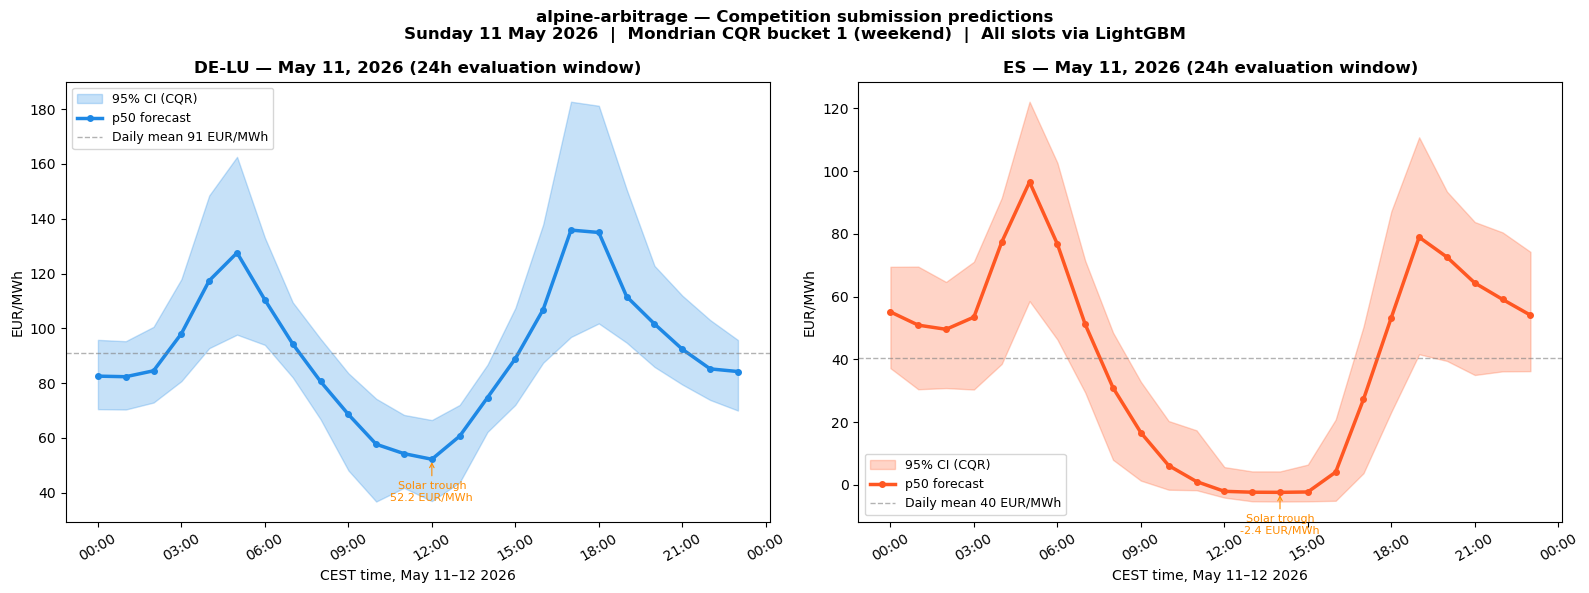

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, zone in zip(axes, ZONES):
    ts   = preds['timestamp']
    p025 = preds[f'{zone} p025']
    p50  = preds[f'{zone} p50']
    p975 = preds[f'{zone} p975']
    ax.fill_between(ts, p025, p975, alpha=0.25, color=ZONE_COLORS[zone], label='95% CI (CQR)')
    ax.plot(ts, p50, lw=2.5, color=ZONE_COLORS[zone], marker='o', ms=4, label='p50 forecast')
    ax.axhline(p50.mean(), color='grey', lw=1, ls='--', alpha=0.6,
               label=f'Daily mean {p50.mean():.0f} EUR/MWh')
    ax.set_title(f'{zone} — May 11, 2026 (24h evaluation window)', fontweight='bold')
    ax.set_ylabel('EUR/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.legend(fontsize=9)
    ax.set_xlabel('CEST time, May 11–12 2026')
    # Annotate solar trough (mid-day)
    mid = p50.idxmin()
    ax.annotate(f'Solar trough\n{p50[mid]:.1f} EUR/MWh',
               xy=(ts[mid], p50[mid]), xytext=(0, -30), textcoords='offset points',
               ha='center', fontsize=8, color='darkorange',
               arrowprops=dict(arrowstyle='->', color='darkorange', lw=0.8))

plt.suptitle('alpine-arbitrage — Competition submission predictions\n'
             'Sunday 11 May 2026  |  Mondrian CQR bucket 1 (weekend)  |  All slots via LightGBM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPO / 'nb_eval_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

In [135]:
# Summary statistics
print('SUBMISSION SUMMARY')
print('=' * 50)
for zone in ZONES:
    p50  = preds[f'{zone} p50']
    p025 = preds[f'{zone} p025']
    p975 = preds[f'{zone} p975']
    print(f'\n{zone}')
    print(f'  Mean p50   : {p50.mean():.2f} EUR/MWh')
    print(f'  Min  p50   : {p50.min():.2f}  @ {preds["timestamp"][p50.idxmin()].strftime("%H:%M CEST")}')
    print(f'  Max  p50   : {p50.max():.2f}  @ {preds["timestamp"][p50.idxmax()].strftime("%H:%M CEST")}')
    print(f'  Mean band  : {(p975-p025).mean():.2f} EUR/MWh (p025→p975)')
    print(f'  Negative p50: {(p50 < 0).sum()} slots')

SUBMISSION SUMMARY

DE-LU
  Mean p50   : 91.15 EUR/MWh
  Min  p50   : 52.22  @ 14:00 CEST
  Max  p50   : 135.85  @ 19:00 CEST
  Mean band  : 39.36 EUR/MWh (p025→p975)
  Negative p50: 0 slots

ES
  Mean p50   : 40.42 EUR/MWh
  Min  p50   : -2.42  @ 16:00 CEST
  Max  p50   : 96.56  @ 07:00 CEST
  Mean band  : 37.73 EUR/MWh (p025→p975)
  Negative p50: 4 slots
